# ArchitectAgent Synthetic Training Dataset - Comprehensive Validation & Cleaning Pipeline

**Dataset:** ~900 JSONL rows generated for fine-tuning an architectural planning ArchitectAgent  
**Purpose:** Data quality assessment, bias detection, cleaning, and before/after evaluation

---

## Table of Contents

| # | Section | Purpose |
|---|---------|---------|
| 0 | Setup & Configuration | Imports, constants, helper functions |
| 1 | Data Loading & JSONL Parsing | Robust line-by-line ingestion with error handling |
| 2 | Plan Chain Reconstruction | Group rows into multi-round planning chains |
| 3 | Structural Schema Validation | Recursive nested key/type/presence checks |
| 4 | Enum & Value Domain Compliance | Allowed-value enforcement, forbidden-stub detection |
| 5 | Cross-Field Consistency | Conditional field rules, issue-ledger/fix-report integrity |
| 6 | Plan Richness & Anti-Stub Analysis | Per-section word counts, specificity scoring, stub detection |
| 7 | Diversity & Coverage Analysis | Project-class spread, capability combinations, entropy metrics |
| 8 | Duplication & Redundancy Detection | Structural fingerprinting, TF-IDF semantic similarity, chain-aware dedup |
| 9 | Bias Detection | Plan-length-by-class, technology concentration, quality-level bias |
| 10 | Chain Progression Validation | Round-sequence integrity, fix-report accuracy, score trajectory |
| 11 | Plan-Contract Alignment Detection | Proxy check for missed spec deviations |
| 12 | Cleaning & Remediation Pipeline | Apply fixes, removals, and rebalancing |
| 13 | Before vs After Evaluation | Quantitative comparison with statistical tests and publication-quality visuals |
| 14 | Statistical Significance Tests | Wilcoxon, Chi-squared, correlation independence |
| 15 | Final Export | Write cleaned dataset and reports |
| 16 | LLM-as-a-Judge Semantic Validation | GPT-based semantic quality gate |

---
## Section 0 - Setup & Configuration

Import all required libraries and define the constants that encode the dataset specification.

In [31]:
import json
import hashlib
import re
import copy
import math
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

print("All imports successful.")

All imports successful.


In [ ]:
ALLOWED_PROJECT_CLASSES = {
    "web_app", "fullstack_app", "mobile_app", "desktop_app", "api_service",
    "static_website", "landing_page", "cli_tool", "library_sdk",
    "automation_tool", "data_pipeline", "ai_system", "research_prototype",
    "infrastructure_project"
}

ALLOWED_CAPABILITIES = {
    "frontend", "backend", "data", "auth", "ai_llm", "integrations",
    "analytics", "realtime", "payments", "admin_panel", "public_api",
    "batch_jobs", "devops"
}

ALLOWED_COMPLEXITY = {"simple", "moderate", "advanced", "high_scale"}
ALLOWED_RISK = {"low", "medium", "high"}
ALLOWED_SENSITIVITY = {"none", "internal", "personal", "financial", "health", "confidential"}
ALLOWED_EXPOSURE = {"local_only", "internal_only", "private_authenticated", "partner_facing", "public_internet"}
ALLOWED_SEVERITY = {"critical", "high", "medium", "low"}
ALLOWED_STATUS = {"unresolved", "resolved", "downgraded", "new"}
ALLOWED_CASE_TYPE = {"first_pass", "revision_round"}
ALLOWED_PLAN_QUALITY = {"low", "moderate", "good", "high"}

FORBIDDEN_COMPACT_VALUES = {
    "webapp", "desktopapp", "mobileapp", "apiservice", "fullstackapp",
    "staticwebsite", "landingpage", "clitool", "librarysdk",
    "automationtool", "datapipeline", "aisystem", "researchprototype",
    "infrastructureproject", "localonly", "internalonly",
    "privateauthenticated", "partnerfacing", "publicinternet",
    "highscale", "adminpanel", "publicapi", "batchjobs", "aillm",
}

# Plan section stub values — single-word or generic filler
STUB_PATTERNS = re.compile(
    r'^(standard|tbd|n\/a|na|todo|none|mvp|default|yes|no|ok|'
    r'as needed|best practices|see above|placeholder|pending|later)$',
    re.IGNORECASE
)

# Mandatory contract fields (snake_case, matching frozen_requirement_contract keys)
MANDATORY_CONTRACT_FIELDS = [
    "project_goal", "target_users", "project_class", "capabilities",
    "complexity_level", "risk_level", "data_sensitivity", "external_exposure",
    "access_model", "feature_scope", "mvp_scope", "security_baseline",
    "frontend_stack", "backend_stack", "data_platform", "hosting_target",
    "privacy_retention_policy", "future_scope", "constraints",
    "observability_baseline", "execution_preference"
]

CONTRACT_FIELD_SUBKEYS = {"value", "source", "confirmed", "rationale", "updated_at"}

# Plan output sections (target_output keys)
MANDATORY_PLAN_KEYS = [
    "thinking_summary", "fix_report", "title", "executive_summary",
    "architecture_overview", "technology_stack", "functional_feature_map",
    "system_components", "workflows", "data_model", "api_design",
    "security_and_compliance", "deployment_and_operations", "observability",
    "cost_and_scaling", "phased_implementation", "development_guidelines",
    "risks_and_tradeoffs", "open_questions_resolved"
]

PLAN_CONTENT_SECTIONS = [
    "executive_summary", "architecture_overview", "technology_stack",
    "functional_feature_map", "system_components", "workflows",
    "data_model", "api_design", "security_and_compliance",
    "deployment_and_operations", "observability", "cost_and_scaling",
    "phased_implementation", "development_guidelines", "risks_and_tradeoffs",
    "open_questions_resolved"
]

VALID_CHANGED_SECTIONS = set(PLAN_CONTENT_SECTIONS + ["title"])

# fix_report item mandatory keys
FIX_REPORT_ITEM_KEYS = {"issue_id", "action_taken", "changed_sections", "expected_outcome"}

# issue_ledger item mandatory keys
ISSUE_LEDGER_ITEM_KEYS = {"id", "title", "severity", "status", "detail"}

# Requirements sections that must be dicts
REQUIRED_REQ_SECTIONS = [
    "project", "frontend", "backend", "security", "data",
    "devops", "constraints", "open_questions", "confirmed_decisions"
]

# Mandatory input_payload keys
MANDATORY_PAYLOAD_KEYS = [
    "round", "frozen_requirement_contract", "requirements",
    "reasoner_reviews", "specialist_subplans", "issue_ledger",
    "focus_issues", "revision_memory", "accepted_exceptions",
    "previous_audits", "previous_plan", "best_plan"
]

# Minimum word count per plan section before flagging as stub
MIN_SECTION_WORDS = 25
STUB_SECTION_WORDS = 5

# Technology specificity terms for plan richness scoring
TECH_TERMS = [
    'kubernetes', 'k8s', 'docker', 'ecs', 'fargate', 'lambda', 'rds',
    'dynamodb', 'postgres', 'mongodb', 'redis', 'kafka', 'rabbitmq',
    'nginx', 'express', 'fastapi', 'django', 'spring', 'react', 'vue',
    'angular', 'flutter', 'swift', 'kotlin', 'terraform', 'helm',
    'argocd', 'github actions', 'datadog', 'prometheus', 'grafana',
    'cloudwatch', 'tls', 'oauth', 'oidc', 'jwt', 'auth0', 'okta',
    'mfa', 'rbac', 'waf', 's3', 'cloudfront', 'alb', 'api gateway',
    'sns', 'sqs', 'openapi', 'graphql', 'grpc', 'websocket', 'sse',
    'sqlite', 'mysql', 'elasticsearch', 'signalr', 'wpf', 'dotnet',
    'supabase', 'firebase', 'vercel', 'netlify', 'heroku', 'gcp', 'azure',
    'aws', 'tailwind', 'nextjs', 'nuxt', 'svelte', 'typescript',
]

DATA_PATH  = "architect_dataset.jsonl"
OUTPUT_DIR = Path("validation_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Constants loaded. Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Constants loaded. Data path: architect_dataset.jsonl
Output directory: validation_output


---
## Section 1 - Data Loading & JSONL Parsing

JSONL format requires line-by-line parsing. Each line is an independent JSON object.
Robust loading handles:
- Empty/whitespace line skipping
- Per-line JSON parse error capture with line numbers
- Duplicate `sample_id` detection
- Pretty-printed and array-wrapped format fallbacks

In [33]:
# ═══════════════════════════════════════════════════════════════
# JSONL LOADER
# ═══════════════════════════════════════════════════════════════

def robust_jsonl_loader(filepath: str) -> tuple:
    """
    Handles all common JSONL corruption patterns:
    - Standard one-JSON-per-line
    - JSON arrays (entire batch pasted as [...])
    - Pretty-printed JSON spanning multiple lines
    - Concatenated objects on same line
    """
    valid_rows = []
    errors = []
    seen_ids = set()

    raw_text = Path(filepath).read_text(encoding='utf-8')

    stripped = raw_text.strip()
    if stripped.startswith('['):
        try:
            arr = json.loads(stripped)
            if isinstance(arr, list):
                for i, item in enumerate(arr):
                    if isinstance(item, dict):
                        sid = item.get('sample_id', '')
                        if sid and sid not in seen_ids:
                            seen_ids.add(sid)
                            valid_rows.append(item)
                        elif sid in seen_ids:
                            errors.append({"source": "array", "error": f"Duplicate: {sid}"})
                    else:
                        errors.append({"source": "array", "error": f"Item {i} not a dict"})
                return valid_rows, errors
        except json.JSONDecodeError:
            pass

    lines = raw_text.split('\n')
    buffer = ""
    brace_depth = 0

    for line_num, line in enumerate(lines, start=1):
        stripped_line = line.strip()
        if not stripped_line:
            continue

        for char in stripped_line:
            if char == '{':
                brace_depth += 1
            elif char == '}':
                brace_depth -= 1

        buffer += stripped_line + " "

        if brace_depth == 0 and buffer.strip():
            candidate = buffer.strip()
            candidate = candidate.strip(',').strip()
            if candidate.startswith('['):
                candidate = candidate[1:]
            if candidate.endswith(']'):
                candidate = candidate[:-1]
            candidate = candidate.strip().strip(',').strip()

            if not candidate:
                buffer = ""
                continue

            try:
                obj = json.loads(candidate)
                if isinstance(obj, dict):
                    sid = obj.get('sample_id', '')
                    if sid and sid not in seen_ids:
                        seen_ids.add(sid)
                        obj['_line_num'] = line_num
                        valid_rows.append(obj)
                    elif sid in seen_ids:
                        errors.append({"line": line_num, "error": f"Duplicate: {sid}"})
                    else:
                        errors.append({"line": line_num, "error": "Missing sample_id"})
                elif isinstance(obj, list):
                    for item in obj:
                        if isinstance(item, dict):
                            sid = item.get('sample_id', '')
                            if sid and sid not in seen_ids:
                                seen_ids.add(sid)
                                item['_line_num'] = line_num
                                valid_rows.append(item)
                buffer = ""
            except json.JSONDecodeError:
                parts = candidate.replace('}{', '}\n{').split('\n')
                if len(parts) > 1:
                    for part in parts:
                        part = part.strip().strip(',').strip()
                        if part:
                            try:
                                obj = json.loads(part)
                                if isinstance(obj, dict):
                                    sid = obj.get('sample_id', '')
                                    if sid and sid not in seen_ids:
                                        seen_ids.add(sid)
                                        obj['_line_num'] = line_num
                                        valid_rows.append(obj)
                            except json.JSONDecodeError:
                                errors.append({"line": line_num, "error": "Parse failed", "preview": part[:100]})
                else:
                    errors.append({"line": line_num, "error": "Parse failed", "preview": candidate[:100]})
                buffer = ""

        if len(buffer) > 500000:
            errors.append({"line": line_num, "error": "Buffer overflow — malformed section"})
            buffer = ""
            brace_depth = 0

    if buffer.strip():
        errors.append({"error": "Unterminated JSON at end of file", "preview": buffer[:100]})

    return valid_rows, errors


rows, load_errors = robust_jsonl_loader(DATA_PATH)

print(f"Loaded: {len(rows)} rows")
print(f"Errors: {len(load_errors)}")
if load_errors:
    for err in load_errors[:10]:
        print(f"  {err}")

ids = sorted([r.get('sample_id', '') for r in rows])
print(f"\nID range: {ids[0]} .. {ids[-1]}")
if len(rows) < 600:
    print("⚠ Still missing rows — check if file has multiple formats mixed")

Loaded: 883 rows
Errors: 1
  {'line': 794, 'error': 'Buffer overflow — malformed section'}

ID range: ARC-PLAN26-001 .. ARC-PLAN26-900


In [34]:
# Basic dataset overview
if rows:
    top_keys = set()
    for r in rows:
        top_keys.update(r.keys())
    top_keys.discard('_line_num')
    print(f"Top-level keys found: {sorted(top_keys)}")

    case_types  = Counter(r.get('metadata', {}).get('case_type', 'MISSING') for r in rows)
    pclasses    = Counter(r.get('profile', {}).get('project_class', 'MISSING') for r in rows)
    pq_dist     = Counter(r.get('metadata', {}).get('plan_quality', 'MISSING') for r in rows)
    agents      = Counter(r.get('agent', 'MISSING') for r in rows)

    print(f"\nCase type distribution : {dict(case_types)}")
    print(f"Project class (top 5) : {dict(pclasses.most_common(5))}")
    print(f"Plan quality dist     : {dict(pq_dist)}")
    print(f"Agent distribution    : {dict(agents)}")
else:
    print("No data loaded. Cannot proceed.")

Top-level keys found: ['agent', 'dataset', 'input_payload', 'metadata', 'profile', 'sample_id', 'split', 'target_output']

Case type distribution : {'revision_round': 527, 'first_pass': 356}
Project class (top 5) : {'desktop_app': 65, 'data_pipeline': 64, 'fullstack_app': 64, 'ai_system': 64, 'static_website': 64}
Plan quality dist     : {'weak': 132, 'moderate': 308, 'strong': 354, 'flawed': 89}
Agent distribution    : {'ArchitectAgent': 883}


---
## Section 2 - Plan Chain Reconstruction

Rows are NOT independent — they form **planning chains**: sequences of rounds for the same
project going through iterative architect-auditor cycles.

Rows within a chain share an identical `frozen_requirement_contract`. Identifying chains is
critical because:
- Near-identical contracts across chain members are **intentional**, not duplicates
- Cross-round validation (fix-report accuracy, progression) only works within chains
- Deduplication must operate at chain level, not row level

In [35]:
def compute_contract_fingerprint(row: Dict) -> str:
    """
    Stable fingerprint from the frozen requirement contract.
    Rows with identical fingerprints belong to the same planning chain.
    """
    contract = row.get('input_payload', {}).get('frozen_requirement_contract', {})
    canonical_parts = []
    for key in sorted(contract.keys()):
        field = contract[key]
        if isinstance(field, dict):
            canonical_parts.append(f"{key}={field.get('value', '')}")
        else:
            canonical_parts.append(f"{key}={field}")
    return hashlib.sha256("|".join(canonical_parts).encode()).hexdigest()[:16]


def reconstruct_chains(rows: List[Dict]) -> Dict[str, List[Dict]]:
    chains = defaultdict(list)
    for row in rows:
        fp = compute_contract_fingerprint(row)
        row['_chain_id'] = fp
        chains[fp].append(row)
    for chain_id in chains:
        chains[chain_id].sort(key=lambda r: r.get('input_payload', {}).get('round', 0))
    return dict(chains)


if rows:
    chains = reconstruct_chains(rows)
    chain_lengths = [len(v) for v in chains.values()]

    print(f"Total chains identified: {len(chains)}")
    print(f"\nChain length distribution:")
    for length in sorted(Counter(chain_lengths)):
        cnt = Counter(chain_lengths)[length]
        print(f"  Length {length}: {cnt} chains ({cnt * length} rows)")
    print(f"  Mean chain length: {np.mean(chain_lengths):.2f}")
    print(f"  Max chain length:  {max(chain_lengths)}")

    single_chains = sum(1 for v in chains.values() if len(v) == 1)
    multi_chains  = sum(1 for v in chains.values() if len(v) > 1)
    print(f"\nSingle-row chains (first_pass only): {single_chains}")
    print(f"Multi-row chains (revision sequences): {multi_chains}")
else:
    chains = {}

Total chains identified: 883

Chain length distribution:
  Length 1: 883 chains (883 rows)
  Mean chain length: 1.00
  Max chain length:  1

Single-row chains (first_pass only): 883
Multi-row chains (revision sequences): 0


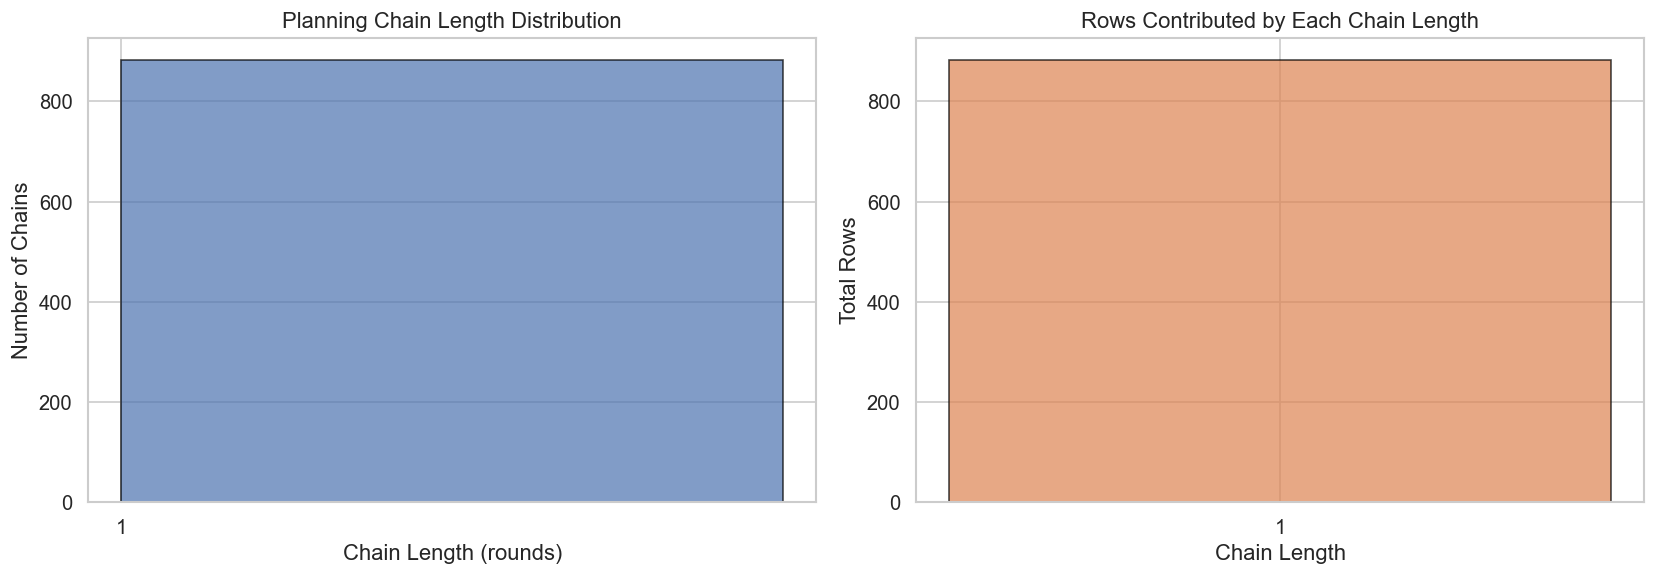

Saved: chain_distribution.png


In [36]:
if chains:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(chain_lengths, bins=range(1, max(chain_lengths) + 2), edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0].set_xlabel('Chain Length (rounds)')
    axes[0].set_ylabel('Number of Chains')
    axes[0].set_title('Planning Chain Length Distribution')
    axes[0].set_xticks(range(1, max(chain_lengths) + 1))

    rows_per_length = defaultdict(int)
    for v in chains.values():
        rows_per_length[len(v)] += len(v)
    lengths = sorted(rows_per_length)
    axes[1].bar(lengths, [rows_per_length[l] for l in lengths], edgecolor='black', alpha=0.7, color='#DD8452')
    axes[1].set_xlabel('Chain Length')
    axes[1].set_ylabel('Total Rows')
    axes[1].set_title('Rows Contributed by Each Chain Length')
    axes[1].set_xticks(lengths)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chain_distribution.png', bbox_inches='tight')
    plt.show()
    print("Saved: chain_distribution.png")

---
## Section 3 - Structural Schema Validation

Recursive schema validator checks every row against the exact nested structure from the
generation prompt. Each violation is categorised:

- **FATAL**: Missing required sections or wrong data types that would crash the runtime
- **ERROR**: Missing required fields within sections
- **WARNING**: Missing optional fields or suspicious types

In [ ]:
class SchemaValidator:
    """Recursive schema validator for ArchitectAgent training rows."""

    def __init__(self):
        self.violations = []

    def reset(self):
        self.violations = []

    def add(self, severity: str, path: str, message: str):
        self.violations.append({"severity": severity, "path": path, "message": message})

    def check_type(self, value, expected_type, path: str, label: str) -> bool:
        if not isinstance(value, expected_type):
            self.add("FATAL", path, f"{label} expected {expected_type.__name__}, got {type(value).__name__}")
            return False
        return True

    def check_key_exists(self, d: dict, key: str, path: str, severity="ERROR") -> bool:
        if key not in d:
            self.add(severity, f"{path}.{key}", f"Missing required key '{key}'")
            return False
        return True

    def validate_contract_field(self, field: dict, path: str):
        if not isinstance(field, dict):
            self.add("FATAL", path, f"Contract field must be dict, got {type(field).__name__}")
            return
        for subkey in CONTRACT_FIELD_SUBKEYS:
            if subkey not in field:
                self.add("ERROR", f"{path}.{subkey}", f"Missing contract sub-key '{subkey}'")
        if 'confirmed' in field and not isinstance(field['confirmed'], bool):
            self.add("WARNING", f"{path}.confirmed", f"'confirmed' should be bool, got {type(field['confirmed']).__name__}")

    def validate_row(self, row: Dict) -> List[Dict]:
        self.reset()

        # Top-level keys
        for key in {"sample_id", "dataset", "agent", "split", "profile", "input_payload", "target_output", "metadata"}:
            self.check_key_exists(row, key, "root", "FATAL")

        # Profile
        profile = row.get('profile', {})
        if self.check_type(profile, dict, "profile", "profile"):
            for pk in ["domain", "project_class", "capabilities", "complexity_level",
                       "risk_level", "data_sensitivity", "external_exposure"]:
                self.check_key_exists(profile, pk, "profile")
            if 'capabilities' in profile and not isinstance(profile['capabilities'], list):
                self.add("ERROR", "profile.capabilities", "Must be a list")

        # Input payload
        payload = row.get('input_payload', {})
        if self.check_type(payload, dict, "input_payload", "input_payload"):
            for pk in MANDATORY_PAYLOAD_KEYS:
                self.check_key_exists(payload, pk, "input_payload")

            # frozen_requirement_contract
            contract = payload.get('frozen_requirement_contract', {})
            if self.check_type(contract, dict, "frozen_requirement_contract", "frozen_requirement_contract"):
                for cf in MANDATORY_CONTRACT_FIELDS:
                    if cf in contract:
                        self.validate_contract_field(contract[cf], f"frozen_requirement_contract.{cf}")

            # requirements sections must be dicts
            reqs = payload.get('requirements', {})
            if isinstance(reqs, dict):
                for section in REQUIRED_REQ_SECTIONS:
                    if section in reqs:
                        if isinstance(reqs[section], list):
                            self.add("ERROR", f"requirements.{section}", "Must be dict, got list")
                        elif not isinstance(reqs[section], dict):
                            self.add("WARNING", f"requirements.{section}", f"Expected dict, got {type(reqs[section]).__name__}")

            # issue_ledger: dict of dicts
            ledger = payload.get('issue_ledger', {})
            if isinstance(ledger, dict):
                for issue_id, issue in ledger.items():
                    if isinstance(issue, dict):
                        for ik in ISSUE_LEDGER_ITEM_KEYS:
                            if ik not in issue:
                                self.add("ERROR", f"issue_ledger.{issue_id}", f"Missing key '{ik}'")

            # focus_issues: list
            fi = payload.get('focus_issues')
            if fi is not None and not isinstance(fi, list):
                self.add("ERROR", "input_payload.focus_issues", "Must be a list")

            # previous_audits: list
            pa = payload.get('previous_audits')
            if pa is not None and not isinstance(pa, list):
                self.add("ERROR", "input_payload.previous_audits", "Must be a list")

        # Target output (the plan)
        output = row.get('target_output', {})
        if self.check_type(output, dict, "target_output", "target_output"):
            for pk in MANDATORY_PLAN_KEYS:
                self.check_key_exists(output, pk, "target_output")

            # fix_report must be a list
            if 'fix_report' in output and not isinstance(output['fix_report'], list):
                self.add("ERROR", "target_output.fix_report", "Must be a list")

            # fix_report item structure
            for i, item in enumerate(output.get('fix_report', [])):
                if isinstance(item, dict):
                    for fk in FIX_REPORT_ITEM_KEYS:
                        if fk not in item:
                            self.add("ERROR", f"target_output.fix_report[{i}]", f"Missing key '{fk}'")
                    if 'changed_sections' in item and not isinstance(item['changed_sections'], list):
                        self.add("ERROR", f"target_output.fix_report[{i}].changed_sections", "Must be a list")

            # Plan sections should be strings or dicts (not lists, not None)
            for section in PLAN_CONTENT_SECTIONS:
                val = output.get(section)
                if val is None:
                    pass
                elif isinstance(val, list):
                    self.add("WARNING", f"target_output.{section}", "Plan section is a list; expected string or dict")

        # Metadata
        meta = row.get('metadata', {})
        if self.check_type(meta, dict, "metadata", "metadata"):
            for mk in ["schema_version", "case_type", "plan_quality", "primary_theme", "generation_source", "quality_flags", "notes"]:
                self.check_key_exists(meta, mk, "metadata")

        return self.violations


if rows:
    validator = SchemaValidator()
    all_violations: Dict[str, List] = {}
    violation_summary = Counter()
    rows_with_fatal = 0

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        viols = validator.validate_row(row)
        if viols:
            all_violations[sid] = viols
            for v in viols:
                violation_summary[v['severity']] += 1
            if any(v['severity'] == 'FATAL' for v in viols):
                rows_with_fatal += 1

    total_violations = sum(violation_summary.values())
    clean_rows = len(rows) - len(all_violations)

    print(f"\n{'='*60}")
    print(f"STRUCTURAL VALIDATION REPORT")
    print(f"{'='*60}")
    print(f"Total rows validated  : {len(rows)}")
    print(f"Rows with violations  : {len(all_violations)} ({len(all_violations)/len(rows)*100:.1f}%)")
    print(f"Rows with FATAL errors: {rows_with_fatal}")
    print(f"Clean rows            : {clean_rows} ({clean_rows/len(rows)*100:.1f}%)")
    print(f"\nViolation breakdown:")
    for sev in ['FATAL', 'ERROR', 'WARNING']:
        print(f"  {sev}: {violation_summary.get(sev, 0)}")

    path_counts = Counter()
    for sid, viols in all_violations.items():
        for v in viols:
            path_counts[v['path']] += 1
    print(f"\nTop 10 most violated paths:")
    for path, count in path_counts.most_common(10):
        print(f"  {path}: {count} occurrences")
else:
    all_violations = {}
    violation_summary = Counter()


STRUCTURAL VALIDATION REPORT
Total rows validated  : 883
Rows with violations  : 0 (0.0%)
Rows with FATAL errors: 0
Clean rows            : 883 (100.0%)

Violation breakdown:
  FATAL: 0
  ERROR: 0

Top 10 most violated paths:


---
## Section 4 - Enum & Value Domain Compliance

Validates every categorical field against allowed sets. Also detects:
- Compact-form values that belong to the Auditor dataset (e.g. "desktopapp" instead of "desktop_app")
- Stub values in plan sections (single-word fillers like "Standard", "TBD")
- Auditor-specific keys leaking into the Architect target_output (e.g. rubric_scores, blocking_issues)

In [ ]:
# Keys that belong to AuditorAgent output — their presence in target_output is a contamination flag
AUDITOR_LEAK_KEYS = {
    "rubric_scores", "rubricscores", "blocking_issues", "blockingissues",
    "issue_updates", "issueupdates", "requirement_conflicts", "requirementconflicts",
    "strengths", "concerns", "recommendations", "summary",
}


def validate_enums(row: Dict) -> List[Dict]:
    """Validate all enum fields against allowed sets and check for Auditor data contamination."""
    issues = []
    profile  = row.get('profile', {})
    contract = row.get('input_payload', {}).get('frozen_requirement_contract', {})
    meta     = row.get('metadata', {})
    output   = row.get('target_output', {})
    ledger   = row.get('input_payload', {}).get('issue_ledger', {})

    # Profile enums
    checks = [
        (profile.get('project_class'),   ALLOWED_PROJECT_CLASSES, 'profile.project_class'),
        (profile.get('complexity_level'), ALLOWED_COMPLEXITY,      'profile.complexity_level'),
        (profile.get('risk_level'),       ALLOWED_RISK,            'profile.risk_level'),
        (profile.get('data_sensitivity'), ALLOWED_SENSITIVITY,     'profile.data_sensitivity'),
        (profile.get('external_exposure'), ALLOWED_EXPOSURE,       'profile.external_exposure'),
    ]
    for value, allowed, path in checks:
        if value and value not in allowed:
            issues.append({"path": path, "value": value, "type": "invalid_enum"})

    for cap in profile.get('capabilities', []):
        if cap not in ALLOWED_CAPABILITIES:
            issues.append({"path": "profile.capabilities", "value": cap, "type": "invalid_capability"})

    # Contract enum values must match profile values
    enum_fields = {
        'project_class':    ('project_class',   ALLOWED_PROJECT_CLASSES),
        'complexity_level': ('complexity_level', ALLOWED_COMPLEXITY),
        'risk_level':       ('risk_level',       ALLOWED_RISK),
        'data_sensitivity': ('data_sensitivity', ALLOWED_SENSITIVITY),
        'external_exposure': ('external_exposure', ALLOWED_EXPOSURE),
    }
    for field, (profile_key, allowed) in enum_fields.items():
        cval = contract.get(field, {}).get('value', '')
        pval = profile.get(profile_key, '')
        if cval and cval not in allowed:
            issues.append({"path": f"contract.{field}", "value": cval, "type": "invalid_contract_enum"})
        if cval and pval and cval != pval:
            issues.append({"path": f"contract.{field}", "value": f"contract='{cval}' vs profile='{pval}'", "type": "contract_profile_mismatch"})

    # issue_ledger entry enums
    for issue_id, issue in ledger.items():
        if isinstance(issue, dict):
            sev = issue.get('severity', '')
            if sev and sev not in ALLOWED_SEVERITY:
                issues.append({"path": f"issue_ledger.{issue_id}.severity", "value": sev, "type": "invalid_severity"})
            status = issue.get('status', '')
            if status and status not in ALLOWED_STATUS:
                issues.append({"path": f"issue_ledger.{issue_id}.status", "value": status, "type": "invalid_status"})

    # Metadata enums
    ct = meta.get('case_type', '')
    if ct and ct not in ALLOWED_CASE_TYPE:
        issues.append({"path": "metadata.case_type", "value": ct, "type": "invalid_case_type"})
    pq = meta.get('plan_quality', '')
    if pq and pq not in ALLOWED_PLAN_QUALITY:
        issues.append({"path": "metadata.plan_quality", "value": pq, "type": "invalid_plan_quality"})

    # Compact-form value scan
    raw_str = json.dumps(row).lower()
    for forbidden in FORBIDDEN_COMPACT_VALUES:
        pattern = r'\b' + re.escape(forbidden) + r'\b'
        if re.search(pattern, raw_str):
            issues.append({"path": "global", "value": forbidden, "type": "compact_form_value"})

    # Auditor key contamination in target_output
    for leak_key in AUDITOR_LEAK_KEYS:
        if leak_key in output:
            issues.append({"path": f"target_output.{leak_key}", "value": leak_key, "type": "auditor_key_leak"})

    # Plan section stub detection
    for section in PLAN_CONTENT_SECTIONS:
        val = output.get(section, '')
        if isinstance(val, str) and val.strip():
            if STUB_PATTERNS.match(val.strip()):
                issues.append({"path": f"target_output.{section}", "value": val.strip()[:50], "type": "stub_section_value"})
            elif len(val.split()) <= STUB_SECTION_WORDS:
                issues.append({"path": f"target_output.{section}", "value": f"{len(val.split())} words", "type": "stub_section_words"})
    return issues


if rows:
    enum_results: Dict[str, List] = {}

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        enum_issues = validate_enums(row)
        if enum_issues:
            enum_results[sid] = enum_issues

    print(f"\n{'='*60}")
    print(f"ENUM & VALUE DOMAIN REPORT")
    print(f"{'='*60}")
    print(f"Rows with enum violations: {len(enum_results)} ({len(enum_results)/len(rows)*100:.1f}%)")

    type_counts = Counter()
    for sid, issues in enum_results.items():
        for iss in issues:
            type_counts[iss['type']] += 1
    print(f"\nViolation types:")
    for t, c in type_counts.most_common():
        print(f"  {t}: {c}")

    # Stub section frequency
    stub_section_counts = Counter()
    for sid, issues in enum_results.items():
        for iss in issues:
            if iss['type'] in ('stub_section_value', 'stub_section_words'):
                stub_section_counts[iss['path'].replace('target_output.', '')] += 1
    if stub_section_counts:
        print(f"\nTop stub-prone sections:")
        for sec, cnt in stub_section_counts.most_common(8):
            print(f"  {sec}: {cnt} rows")
else:
    enum_results = {}


ENUM & VALUE DOMAIN REPORT
Rows with enum violations: 579 (65.6%)

Violation types:
  invalid_plan_quality: 575
  compact_form_value: 13


---
## Section 5 - Cross-Field Consistency Validation

Checks the logical invariants that must hold across fields within each row:

1. **first_pass invariants**: round=1, empty previous_audits, empty issue_ledger, empty fix_report
2. **revision_round invariants**: round>1, non-empty previous_audits, non-empty issue_ledger, non-empty fix_report
3. **fix_report integrity**: every issue_id in fix_report must exist in issue_ledger
4. **focus_issues integrity**: every focus issue must exist in issue_ledger
5. **Conditional contract fields**: llm_integration required when capabilities include ai_llm; compliance_context required for high-risk/sensitive profiles
6. **revision_memory consistency**: resolved/unresolved IDs reference actual issue_ledger entries

In [ ]:
def validate_cross_field(row: Dict) -> List[Dict]:
    issues = []
    profile  = row.get('profile', {})
    payload  = row.get('input_payload', {})
    output   = row.get('target_output', {})
    meta     = row.get('metadata', {})
    contract = payload.get('frozen_requirement_contract', {})
    ledger   = payload.get('issue_ledger', {})
    round_num = payload.get('round', 1)
    case_type = meta.get('case_type', '')
    capabilities = profile.get('capabilities', [])
    risk      = profile.get('risk_level', '')
    sensitivity = profile.get('data_sensitivity', '')

    # 1. Conditional contract field: llm_integration
    if 'ai_llm' in capabilities and 'llm_integration' not in contract:
        issues.append({"rule": "conditional_llm", "severity": "ERROR", "detail": "capabilities includes 'ai_llm' but contract missing 'llm_integration'"})

    # 2. Conditional contract field: compliance_context
    needs_compliance = (
        risk == 'high' or
        sensitivity in ('personal', 'financial', 'health', 'confidential') or
        'payments' in capabilities
    )
    if needs_compliance and 'compliance_context' not in contract:
        issues.append({"rule": "conditional_compliance", "severity": "ERROR", "detail": f"risk={risk}, sensitivity={sensitivity} requires 'compliance_context'"})

    # 3. first_pass invariants
    if case_type == 'first_pass':
        if round_num != 1:
            issues.append({"rule": "first_pass_round", "severity": "WARNING", "detail": f"first_pass but round={round_num} (expected 1)"})
        if payload.get('previous_audits') and len(payload['previous_audits']) > 0:
            issues.append({"rule": "first_pass_prevaudits", "severity": "WARNING", "detail": "first_pass should have empty previous_audits"})
        if ledger:
            issues.append({"rule": "first_pass_ledger", "severity": "WARNING", "detail": f"first_pass should have empty issue_ledger, found {len(ledger)} entries"})
        fix_report = output.get('fix_report', [])
        if fix_report and len(fix_report) > 0:
            issues.append({"rule": "first_pass_fixreport", "severity": "WARNING", "detail": "first_pass should have empty fix_report"})

    # 4. revision_round invariants
    if case_type == 'revision_round':
        if round_num <= 1:
            issues.append({"rule": "revision_round_num", "severity": "ERROR", "detail": f"revision_round but round={round_num} (expected > 1)"})
        if not payload.get('previous_audits') or len(payload['previous_audits']) == 0:
            issues.append({"rule": "revision_no_prevaudits", "severity": "ERROR", "detail": "revision_round must have non-empty previous_audits"})
        if not ledger:
            issues.append({"rule": "revision_no_ledger", "severity": "ERROR", "detail": "revision_round must have non-empty issue_ledger"})
        fix_report = output.get('fix_report', [])
        if not fix_report or len(fix_report) == 0:
            issues.append({"rule": "revision_no_fixreport", "severity": "WARNING", "detail": "revision_round should have non-empty fix_report"})

    # 5. fix_report issue_ids must exist in issue_ledger
    fix_report = output.get('fix_report', [])
    ledger_ids = set(ledger.keys())
    for i, item in enumerate(fix_report):
        if isinstance(item, dict):
            fid = item.get('issue_id', '')
            if fid and fid not in ledger_ids:
                issues.append({"rule": "fixreport_orphan_id", "severity": "ERROR", "detail": f"fix_report[{i}].issue_id='{fid}' not in issue_ledger"})
            # changed_sections must be valid plan section names
            for sec in item.get('changed_sections', []):
                if sec not in VALID_CHANGED_SECTIONS:
                    issues.append({"rule": "fixreport_invalid_section", "severity": "WARNING", "detail": f"fix_report[{i}].changed_sections contains invalid section '{sec}'"})

    # 6. focus_issues must reference issue_ledger entries
    focus_issues = payload.get('focus_issues', [])
    for i, fi in enumerate(focus_issues):
        if isinstance(fi, dict):
            fid = fi.get('id', '')
            if fid and fid not in ledger_ids:
                issues.append({"rule": "focus_issue_orphan", "severity": "ERROR", "detail": f"focus_issues[{i}].id='{fid}' not in issue_ledger"})
        elif isinstance(fi, str):
            if fi and fi not in ledger_ids:
                issues.append({"rule": "focus_issue_orphan", "severity": "ERROR", "detail": f"focus_issues[{i}]='{fi}' not in issue_ledger"})

    # 7. revision_memory consistency
    rev_mem = payload.get('revision_memory', {})
    if isinstance(rev_mem, dict) and ledger:
        for rid in rev_mem.get('resolved_issue_ids', []):
            if rid not in ledger_ids:
                issues.append({"rule": "revmem_resolved_orphan", "severity": "WARNING", "detail": f"revision_memory.resolved_issue_ids contains '{rid}' not in issue_ledger"})
        for uid in rev_mem.get('unresolved_issue_ids', []):
            if uid not in ledger_ids:
                issues.append({"rule": "revmem_unresolved_orphan", "severity": "WARNING", "detail": f"revision_memory.unresolved_issue_ids contains '{uid}' not in issue_ledger"})
        # Resolved IDs in revision_memory should actually be resolved in ledger
        for rid in rev_mem.get('resolved_issue_ids', []):
            if rid in ledger and isinstance(ledger[rid], dict):
                if ledger[rid].get('status', '') != 'resolved':
                    issues.append({"rule": "revmem_status_mismatch", "severity": "WARNING", "detail": f"revision_memory claims '{rid}' resolved but ledger.status='{ledger[rid].get('status')}'"})

    return issues


if rows:
    crossfield_results: Dict[str, List] = {}
    rule_counts = Counter()

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        cf_issues = validate_cross_field(row)
        if cf_issues:
            crossfield_results[sid] = cf_issues
            for iss in cf_issues:
                rule_counts[iss['rule']] += 1

    print(f"\n{'='*60}")
    print(f"CROSS-FIELD CONSISTENCY REPORT")
    print(f"{'='*60}")
    print(f"Rows with cross-field issues: {len(crossfield_results)} ({len(crossfield_results)/len(rows)*100:.1f}%)")
    print(f"\nRule violation counts:")
    for rule, cnt in rule_counts.most_common():
        print(f"  {rule}: {cnt}")
else:
    crossfield_results = {}


CROSS-FIELD CONSISTENCY REPORT
Rows with cross-field issues: 12 (1.4%)

Rule violation counts:
  fixreport_invalid_section: 8
  revmem_resolved_orphan: 8


---
## Section 6 - Plan Richness & Anti-Stub Analysis

The Architect dataset's equivalent of score calibration. Since target_output is the plan
itself (not an audit), quality is measured by:

1. **Section word counts**: each of 16 content sections must exceed the minimum threshold
2. **Technology specificity**: count of named technologies across the plan
3. **Anti-stub detection**: identify rows where the plan is padded with generic filler
4. **Fix-report depth**: action_taken and expected_outcome must be substantive
5. **Plan-quality vs richness correlation**: metadata.plan_quality should correlate with measured richness

In [ ]:
def compute_plan_richness(output: Dict) -> Dict[str, Any]:
    """Compute richness metrics for a plan's target_output."""
    section_words = {}
    total_words = 0
    stub_sections = []

    for section in PLAN_CONTENT_SECTIONS:
        val = output.get(section, '')
        if isinstance(val, dict):
            text = json.dumps(val)
        elif isinstance(val, list):
            text = ' '.join(str(v) for v in val)
        else:
            text = str(val or '')
        wc = len(text.split())
        section_words[section] = wc
        total_words += wc
        if wc <= STUB_SECTION_WORDS:
            stub_sections.append(section)

    plan_text = ' '.join(
        json.dumps(output.get(s, '')) if isinstance(output.get(s, ''), dict)
        else str(output.get(s, ''))
        for s in PLAN_CONTENT_SECTIONS
    ).lower()

    tech_count = sum(1 for t in TECH_TERMS if t in plan_text)

    # fix_report depth
    fix_items = output.get('fix_report', [])
    fix_depth_scores = []
    for item in fix_items:
        if isinstance(item, dict):
            at_words = len(str(item.get('action_taken', '')).split())
            eo_words = len(str(item.get('expected_outcome', '')).split())
            fix_depth_scores.append(at_words + eo_words)

    return {
        "section_words":       section_words,
        "total_words":         total_words,
        "mean_section_words":  total_words / max(len(PLAN_CONTENT_SECTIONS), 1),
        "stub_sections":       stub_sections,
        "stub_section_count":  len(stub_sections),
        "tech_term_count":     tech_count,
        "specificity_score":   min(10.0, tech_count * 0.7),
        "fix_report_depth":    np.mean(fix_depth_scores) if fix_depth_scores else 0.0,
        "is_stub_plan":        len(stub_sections) >= 4 or total_words < 200,
    }


def validate_plan_richness(row: Dict) -> Tuple[List[Dict], Dict]:
    """Flag richness violations and return the richness dict."""    
    issues = []
    output = row.get('target_output', {})
    meta   = row.get('metadata', {})
    richness = compute_plan_richness(output)

    if richness['is_stub_plan']:
        issues.append({"type": "stub_plan", "detail":
                        f"Plan has {richness['stub_section_count']} stub sections "
                        f"and only {richness['total_words']} total words"})

    if richness['stub_sections']:
        issues.append({"type": "stub_sections", "detail": f"Stub sections: {richness['stub_sections']}"})

    if richness['tech_term_count'] < 3:
        issues.append({"type": "low_specificity", "detail": f"Only {richness['tech_term_count']} named technology terms"})

    # Plan quality metadata vs actual richness
    plan_quality = meta.get('plan_quality', '')
    if plan_quality in ('good', 'high') and richness['total_words'] < 400:
        issues.append({"type": "quality_inflation", "detail": f"plan_quality='{plan_quality}' but total_words={richness['total_words']}"})
    if plan_quality in ('low',) and richness['total_words'] > 1500:
        issues.append({"type": "quality_underrating", "detail": f"plan_quality='{plan_quality}' but total_words={richness['total_words']}"})

    return issues, richness


if rows:
    richness_results:    Dict[str, List]  = {}
    richness_data:       Dict[str, Dict]  = {}

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        r_issues, r_data = validate_plan_richness(row)
        richness_data[sid] = r_data
        if r_issues:
            richness_results[sid] = r_issues

    rich_df = pd.DataFrame([
        {
            'sample_id':        sid,
            'total_words':      d['total_words'],
            'stub_count':       d['stub_section_count'],
            'tech_terms':       d['tech_term_count'],
            'specificity':      d['specificity_score'],
            'fix_depth':        d['fix_report_depth'],
            'is_stub_plan':     d['is_stub_plan'],
            'plan_quality':     rows[[r.get('sample_id') for r in rows].index(sid)].get('metadata', {}).get('plan_quality', '') if sid in [r.get('sample_id') for r in rows] else '',
        }
        for sid, d in richness_data.items()
    ])

    print(f"\n{'='*60}")
    print(f"PLAN RICHNESS REPORT")
    print(f"{'='*60}")
    print(f"Rows with richness issues : {len(richness_results)} ({len(richness_results)/len(rows)*100:.1f}%)")
    print(f"Stub plans (>=4 stub secs): {rich_df['is_stub_plan'].sum()}")
    print(f"\nWord count statistics:")
    print(rich_df['total_words'].describe().to_string())
    print(f"\nPlan quality vs mean words:")
    for pq, grp in rich_df.groupby('plan_quality'):
        print(f"  {pq}: mean={grp['total_words'].mean():.0f}  median={grp['total_words'].median():.0f}")

    # Plan-quality / richness correlation
    if len(rich_df) > 5:
        pq_map = {'low': 1, 'moderate': 2, 'good': 3, 'high': 4}
        rich_df['pq_num'] = rich_df['plan_quality'].map(pq_map)
        valid_corr = rich_df.dropna(subset=['pq_num'])
        if len(valid_corr) > 5:
            r, p = stats.pearsonr(valid_corr['pq_num'], valid_corr['total_words'])
            print(f"\nPlan quality ↔ total_words correlation: r={r:.3f}, p={p:.4f}")
            if abs(r) < 0.3:
                print("  ⚠ Weak correlation — plan_quality labels may not reflect actual plan richness")
else:
    richness_results = {}
    richness_data    = {}
    rich_df          = pd.DataFrame()


PLAN RICHNESS REPORT
Rows with richness issues : 5 (0.6%)
Stub plans (>=4 stub secs): 0

Word count statistics:
count     883.000000
mean     1428.403171
std       251.215992
min       793.000000
25%      1252.500000
50%      1420.000000
75%      1603.000000
max      2299.000000

Plan quality vs mean words:
  flawed: mean=1345  median=1316
  moderate: mean=1445  median=1438
  strong: mean=1511  median=1500
  weak: mean=1225  median=1214

Plan quality ↔ total_words correlation: r=nan, p=nan


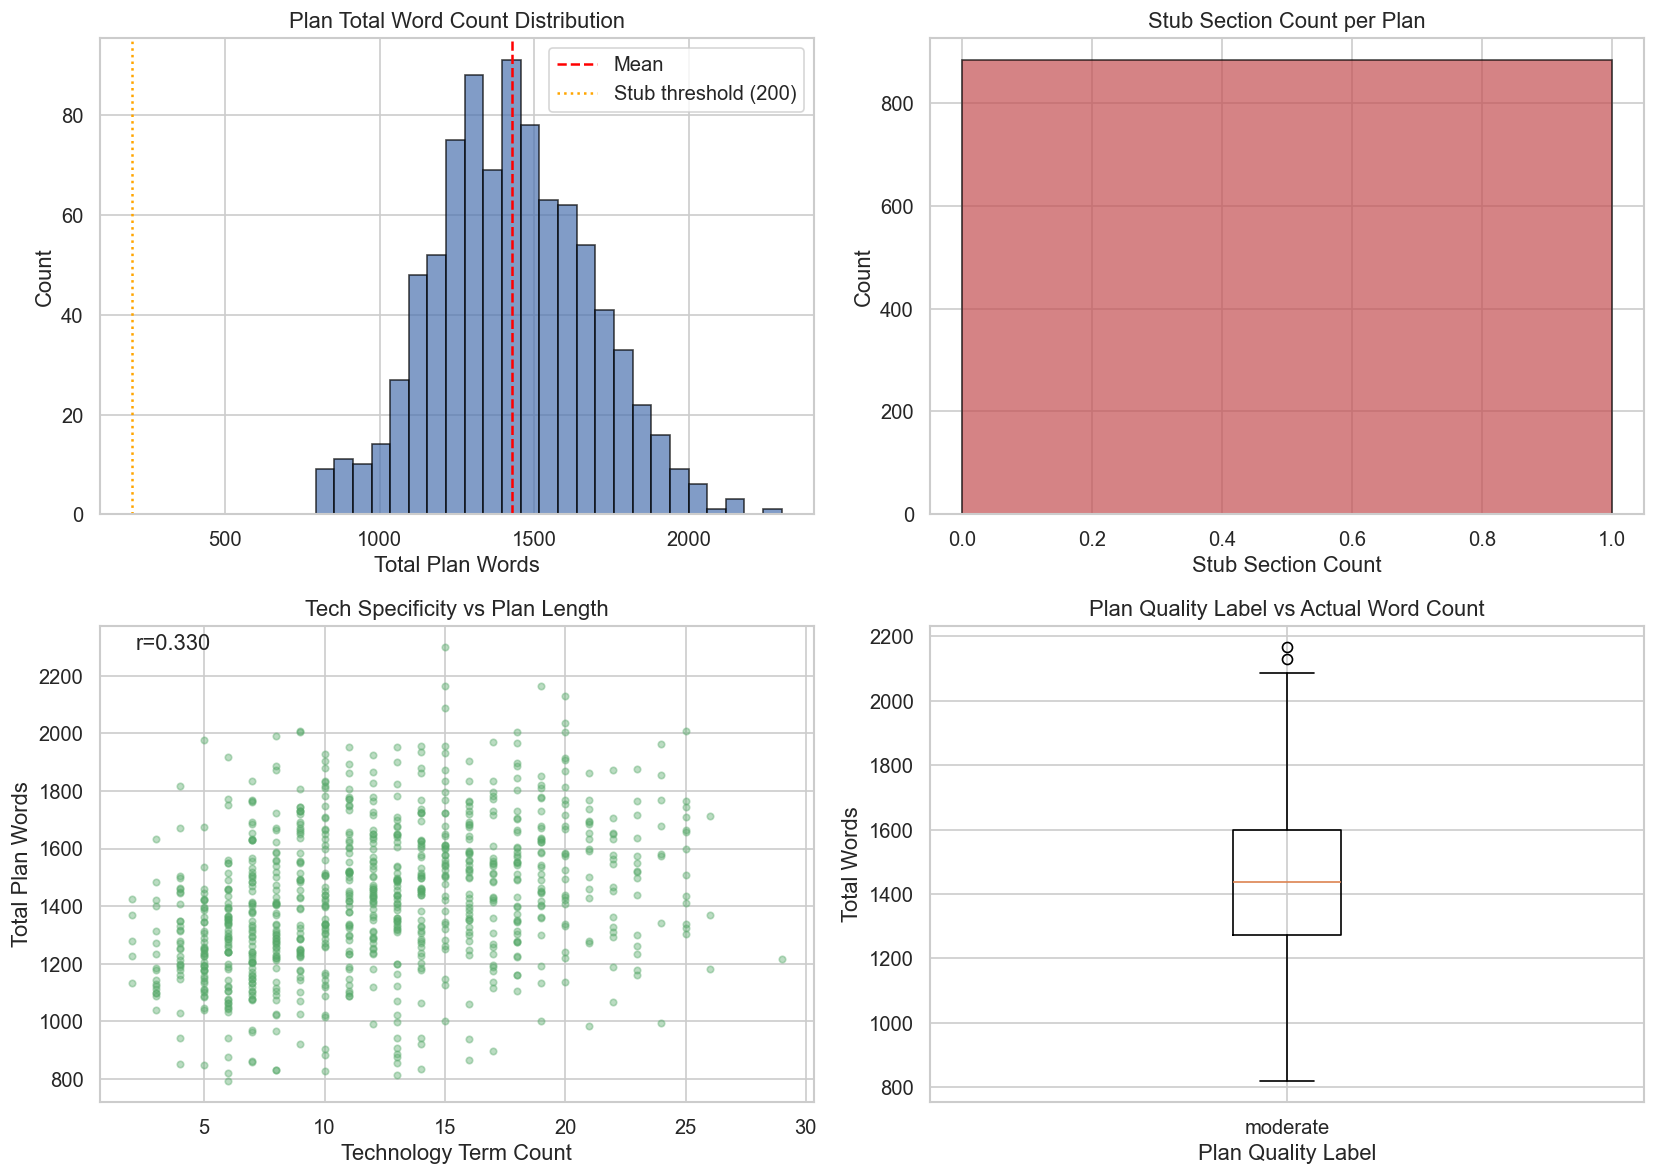

Saved: plan_richness.png


In [ ]:
if len(rich_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(rich_df['total_words'], bins=25, edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0, 0].axvline(rich_df['total_words'].mean(), color='red', linestyle='--', label='Mean')
    axes[0, 0].axvline(200, color='orange', linestyle=':', label='Stub threshold (200)')
    axes[0, 0].set_xlabel('Total Plan Words')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Plan Total Word Count Distribution')
    axes[0, 0].legend()

    axes[0, 1].hist(rich_df['stub_count'], bins=range(0, int(rich_df['stub_count'].max()) + 2), edgecolor='black', alpha=0.7, color='#C44E52')
    axes[0, 1].set_xlabel('Stub Section Count')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Stub Section Count per Plan')

    axes[1, 0].scatter(rich_df['tech_terms'], rich_df['total_words'], alpha=0.4, s=15, color='#55A868')
    axes[1, 0].set_xlabel('Technology Term Count')
    axes[1, 0].set_ylabel('Total Plan Words')
    axes[1, 0].set_title('Tech Specificity vs Plan Length')
    if len(rich_df) > 2:
        r, _ = stats.pearsonr(rich_df['tech_terms'], rich_df['total_words'])
        axes[1, 0].annotate(f'r={r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction')

    pq_order = ['low', 'moderate', 'good', 'high']
    pq_present = [p for p in pq_order if p in rich_df['plan_quality'].values]
    if pq_present:
        data_by_pq = [rich_df[rich_df['plan_quality'] == p]['total_words'].values for p in pq_present]
        axes[1, 1].boxplot(data_by_pq, labels=pq_present)
        axes[1, 1].set_xlabel('Plan Quality Label')
        axes[1, 1].set_ylabel('Total Words')
        axes[1, 1].set_title('Plan Quality Label vs Actual Word Count')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plan_richness.png', bbox_inches='tight')
    plt.show()
    print("Saved: plan_richness.png")

---
## Section 7 - Diversity & Coverage Analysis

Measures how well the dataset covers the operational surface of the runtime:
- Project-class distribution (Shannon entropy)
- Capability combination diversity
- first_pass / revision_round ratio (target: 40/60)
- Plan quality distribution
- Architecture theme concentration

In [42]:
def compute_shannon_entropy(counts: Dict) -> float:
    total = sum(counts.values())
    if total == 0:
        return 0.0
    probs = [c / total for c in counts.values() if c > 0]
    return -sum(p * math.log2(p) for p in probs)

def compute_max_entropy(n: int) -> float:
    return math.log2(n) if n > 1 else 0.0


if rows:
    pc_counts  = Counter(r.get('profile', {}).get('project_class', 'MISSING') for r in rows)
    pq_counts  = Counter(r.get('metadata', {}).get('plan_quality', 'MISSING') for r in rows)
    theme_counts = Counter(r.get('metadata', {}).get('primary_theme', 'MISSING') for r in rows)

    entropy_pc  = compute_shannon_entropy(pc_counts)
    max_ent_pc  = compute_max_entropy(len(ALLOWED_PROJECT_CLASSES))
    norm_ent_pc = entropy_pc / max_ent_pc if max_ent_pc > 0 else 0

    print(f"{'='*60}")
    print(f"DIVERSITY & COVERAGE REPORT")
    print(f"{'='*60}")
    print(f"\n── Project Class Distribution ──")
    print(f"Entropy: {entropy_pc:.3f} / {max_ent_pc:.3f} (normalised: {norm_ent_pc:.3f})")
    print(f"Classes represented: {len(pc_counts)} / {len(ALLOWED_PROJECT_CLASSES)}")

    missing_classes = ALLOWED_PROJECT_CLASSES - set(pc_counts.keys())
    if missing_classes:
        print(f"Missing classes: {missing_classes}")
    under_rep = {k: v for k, v in pc_counts.items() if v < len(rows) * 0.02}
    over_rep  = {k: v for k, v in pc_counts.items() if v > len(rows) * 0.15}
    if under_rep:
        print(f"Under-represented (<2%): {under_rep}")
    if over_rep:
        print(f"Over-represented (>15%): {over_rep}")

    cap_combos = Counter(
        tuple(sorted(r.get('profile', {}).get('capabilities', []))) for r in rows
    )
    print(f"\n── Capability Combinations ──")
    print(f"Unique combinations: {len(cap_combos)}")
    print(f"Top 5 combinations:")
    for combo, count in cap_combos.most_common(5):
        print(f"  {combo}: {count}")

    fp_count = sum(1 for r in rows if r.get('metadata', {}).get('case_type') == 'first_pass')
    rr_count = sum(1 for r in rows if r.get('metadata', {}).get('case_type') == 'revision_round')
    total_typed = fp_count + rr_count
    ratio_dev   = abs(fp_count / max(total_typed, 1) - 0.40)
    print(f"\n── Case Type Ratio ──")
    print(f"first_pass:     {fp_count} ({fp_count/max(total_typed,1)*100:.1f}%) — target: 40%")
    print(f"revision_round: {rr_count} ({rr_count/max(total_typed,1)*100:.1f}%) — target: 60%")
    print(f"Deviation from target: {ratio_dev*100:.1f}pp")

    entropy_pq = compute_shannon_entropy(pq_counts)
    print(f"\n── Plan Quality Distribution ──")
    print(f"Entropy: {entropy_pq:.3f}")
    for pq, cnt in pq_counts.most_common():
        print(f"  {pq}: {cnt} ({cnt/len(rows)*100:.1f}%)")

    print(f"\n── Architecture Theme Distribution ──")
    print(f"Unique themes: {len(theme_counts)}")
    print(f"Top 8 themes:")
    for theme, cnt in theme_counts.most_common(8):
        print(f"  {theme}: {cnt}")


DIVERSITY & COVERAGE REPORT

── Project Class Distribution ──
Entropy: 3.807 / 3.807 (normalised: 1.000)
Classes represented: 14 / 14

── Capability Combinations ──
Unique combinations: 213
Top 5 combinations:
  ('analytics', 'frontend'): 114
  ('backend', 'data', 'integrations'): 63
  ('analytics', 'batch_jobs', 'data', 'integrations'): 26
  ('backend', 'data'): 25
  ('backend', 'batch_jobs', 'data', 'integrations'): 20

── Case Type Ratio ──
first_pass:     356 (40.3%) — target: 40%
revision_round: 527 (59.7%) — target: 60%
Deviation from target: 0.3pp

── Plan Quality Distribution ──
Entropy: 1.802
  strong: 354 (40.1%)
  moderate: 308 (34.9%)
  weak: 132 (14.9%)
  flawed: 89 (10.1%)

── Architecture Theme Distribution ──
Unique themes: 14
Top 8 themes:
  scalability: 64
  ml_pipeline: 64
  realtime: 64
  data_intensive: 64
  microservices_decomposition: 64
  greenfield: 64
  performance_optimization: 63
  cost_reduction: 63


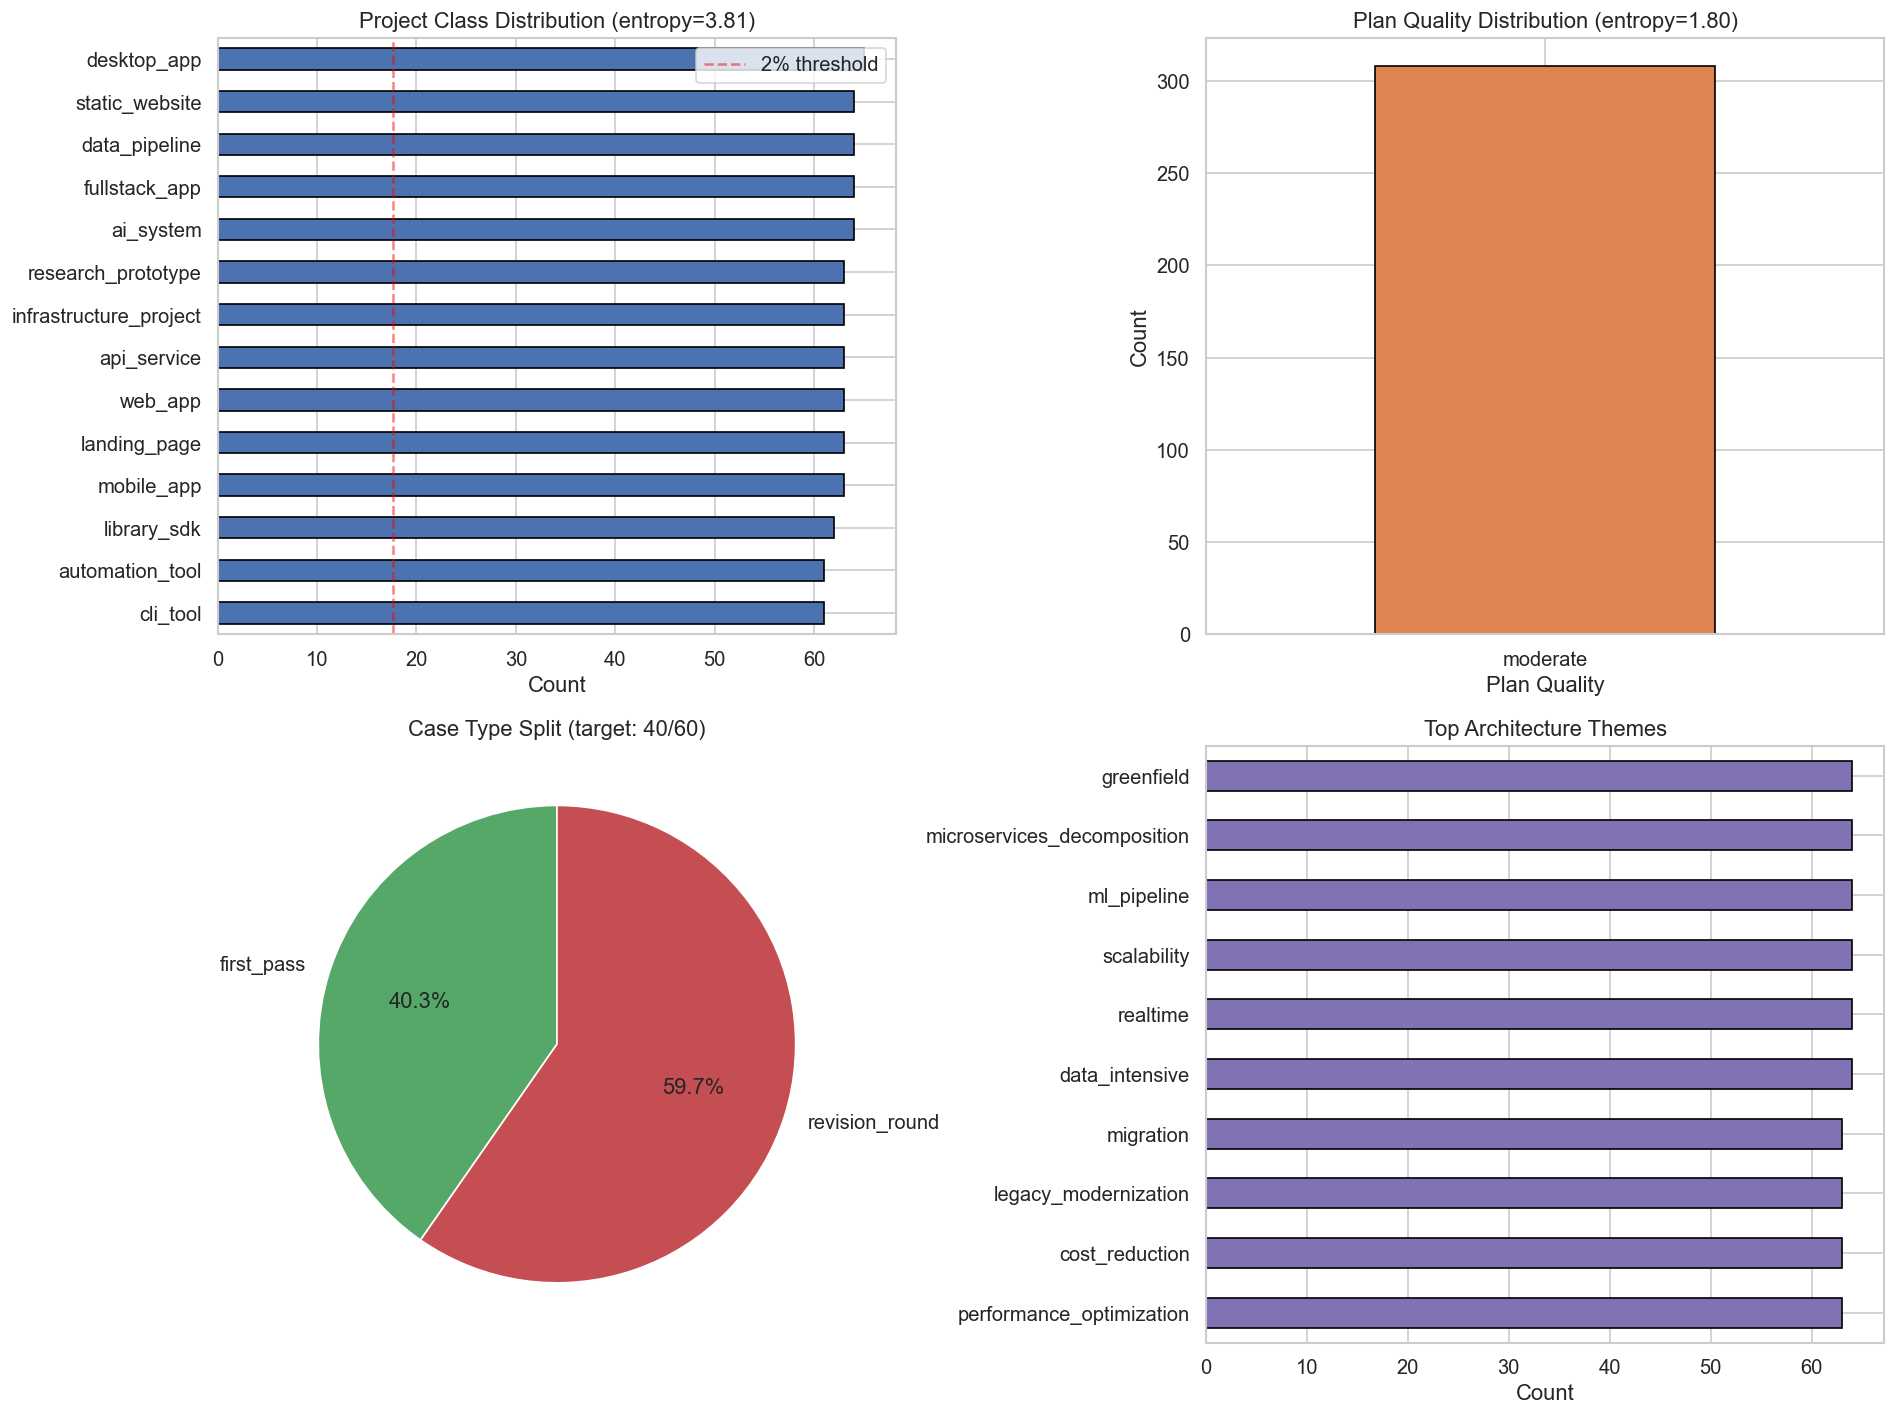

Saved: diversity_coverage.png


In [ ]:
if rows:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    pc_series = pd.Series(pc_counts).sort_values(ascending=True)
    pc_series.plot(kind='barh', ax=axes[0, 0], color='#4C72B0', edgecolor='black')
    axes[0, 0].set_xlabel('Count')
    axes[0, 0].set_title(f'Project Class Distribution (entropy={entropy_pc:.2f})')
    axes[0, 0].axvline(len(rows) * 0.02, color='red', linestyle='--', alpha=0.5, label='2% threshold')
    axes[0, 0].legend()

    pq_series = pd.Series(pq_counts)
    pq_series = pq_series.reindex(['low', 'moderate', 'good', 'high']).dropna()
    pq_series.plot(kind='bar', ax=axes[0, 1], color='#DD8452', edgecolor='black')
    axes[0, 1].set_xlabel('Plan Quality')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title(f'Plan Quality Distribution (entropy={entropy_pq:.2f})')
    axes[0, 1].tick_params(axis='x', rotation=0)

    axes[1, 0].pie([fp_count, rr_count], labels=['first_pass', 'revision_round'], autopct='%1.1f%%', colors=['#55A868', '#C44E52'], startangle=90)
    axes[1, 0].set_title('Case Type Split (target: 40/60)')

    top_themes = dict(theme_counts.most_common(10))
    theme_s = pd.Series(top_themes).sort_values()
    theme_s.plot(kind='barh', ax=axes[1, 1], color='#8172B3', edgecolor='black')
    axes[1, 1].set_xlabel('Count')
    axes[1, 1].set_title('Top Architecture Themes')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'diversity_coverage.png', bbox_inches='tight')
    plt.show()
    print("Saved: diversity_coverage.png")

---
## Section 8 - Duplication & Redundancy Detection

Three levels of deduplication, all **chain-aware** (rows within the same planning chain
share an identical contract by design — they are NOT duplicates):

1. **Exact deduplication**: SHA-256 hash of row content (excluding metadata fields)
2. **Structural fingerprinting**: feature vector from categorical fields + plan theme + issue count
3. **Semantic similarity**: TF-IDF of plan text, cosine similarity, hierarchical clustering

In [44]:
def get_content_hash(row: Dict) -> str:
    clean = {k: v for k, v in row.items()
             if k not in ('_line_num', '_chain_id', 'sample_id')}
    return hashlib.sha256(json.dumps(clean, sort_keys=True, ensure_ascii=False).encode()).hexdigest()


def get_structural_fingerprint(row: Dict) -> str:
    profile = row.get('profile', {})
    meta    = row.get('metadata', {})
    payload = row.get('input_payload', {})
    output  = row.get('target_output', {})

    ledger   = payload.get('issue_ledger', {})
    fix_rpt  = output.get('fix_report', [])

    parts = [
        profile.get('project_class', ''),
        ','.join(sorted(profile.get('capabilities', []))),
        profile.get('risk_level', ''),
        profile.get('data_sensitivity', ''),
        str(payload.get('round', '')),
        meta.get('case_type', ''),
        meta.get('plan_quality', ''),
        meta.get('primary_theme', ''),
        str(len(ledger)),
        str(len(fix_rpt)),
    ]

    issue_ids = sorted(ledger.keys())
    parts.append(','.join(issue_ids))
    return '|'.join(parts)


def extract_text_for_similarity(row: Dict) -> str:
    output = row.get('target_output', {})
    parts  = []
    for section in PLAN_CONTENT_SECTIONS:
        val = output.get(section, '')
        if isinstance(val, dict):
            parts.append(json.dumps(val))
        elif isinstance(val, list):
            parts.append(' '.join(str(v) for v in val))
        elif isinstance(val, str) and val:
            parts.append(val)
    parts.append(str(output.get('thinking_summary', '')))
    return ' '.join(parts)


if rows:
    # 1. Exact hash deduplication
    hash_map = defaultdict(list)
    for row in rows:
        hash_map[get_content_hash(row)].append(row.get('sample_id', 'UNKNOWN'))
    exact_dupes = {h: ids for h, ids in hash_map.items() if len(ids) > 1}

    # 2. Structural fingerprint deduplication (cross-chain only)
    fp_map = defaultdict(list)
    for row in rows:
        fp_map[get_structural_fingerprint(row)].append(
            (row.get('sample_id', 'UNKNOWN'), row.get('_chain_id', ''))
        )
    structural_dupes = {
        fp: entries for fp, entries in fp_map.items()
        if len(set(e[1] for e in entries)) > 1
    }

    print(f"\n{'='*60}")
    print(f"DUPLICATION & REDUNDANCY REPORT")
    print(f"{'='*60}")
    print(f"\n── Exact Duplicates ──")
    print(f"Duplicate groups: {len(exact_dupes)}")
    if exact_dupes:
        for h, ids in list(exact_dupes.items())[:5]:
            print(f"  {ids}")

    print(f"\n── Structural Fingerprint Duplicates (cross-chain) ──")
    print(f"Duplicate groups: {len(structural_dupes)}")
    if structural_dupes:
        for fp, entries in list(structural_dupes.items())[:5]:
            print(f"  {[e[0] for e in entries]}")

    # 3. TF-IDF semantic similarity
    print(f"\n── Semantic Similarity (TF-IDF) ──")
    texts    = [extract_text_for_similarity(r) for r in rows]
    text_ids = [r.get('sample_id', '') for r in rows]

    if len(texts) > 5:
        vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix   = cosine_similarity(tfidf_matrix).astype(np.float32)
        np.fill_diagonal(sim_matrix, 0)

        # Cross-chain pairs above threshold
        HIGH_SIM_THRESHOLD = 0.85
        near_dupes = []
        for i in range(len(rows)):
            for j in range(i + 1, len(rows)):
                if rows[i].get('_chain_id') != rows[j].get('_chain_id'):
                    if sim_matrix[i, j] >= HIGH_SIM_THRESHOLD:
                        near_dupes.append({
                            "row_a": text_ids[i], "row_b": text_ids[j],
                            "similarity": float(sim_matrix[i, j])
                        })

        print(f"High-similarity cross-chain pairs (≥{HIGH_SIM_THRESHOLD}): {len(near_dupes)}")
        if near_dupes:
            for nd in near_dupes[:5]:
                print(f"  {nd['row_a']} ↔ {nd['row_b']}: {nd['similarity']:.3f}")
    else:
        sim_matrix = None
        near_dupes = []
else:
    exact_dupes    = {}
    structural_dupes = {}
    sim_matrix     = None
    near_dupes     = []


DUPLICATION & REDUNDANCY REPORT

── Exact Duplicates ──
Duplicate groups: 0

── Structural Fingerprint Duplicates (cross-chain) ──
Duplicate groups: 19
  ['ARC-PLAN26-040', 'ARC-PLAN26-051']
  ['ARC-PLAN26-045', 'ARC-PLAN26-723']
  ['ARC-PLAN26-066', 'ARC-PLAN26-071']
  ['ARC-PLAN26-099', 'ARC-PLAN26-106']
  ['ARC-PLAN26-129', 'ARC-PLAN26-503']

── Semantic Similarity (TF-IDF) ──
High-similarity cross-chain pairs (≥0.85): 0


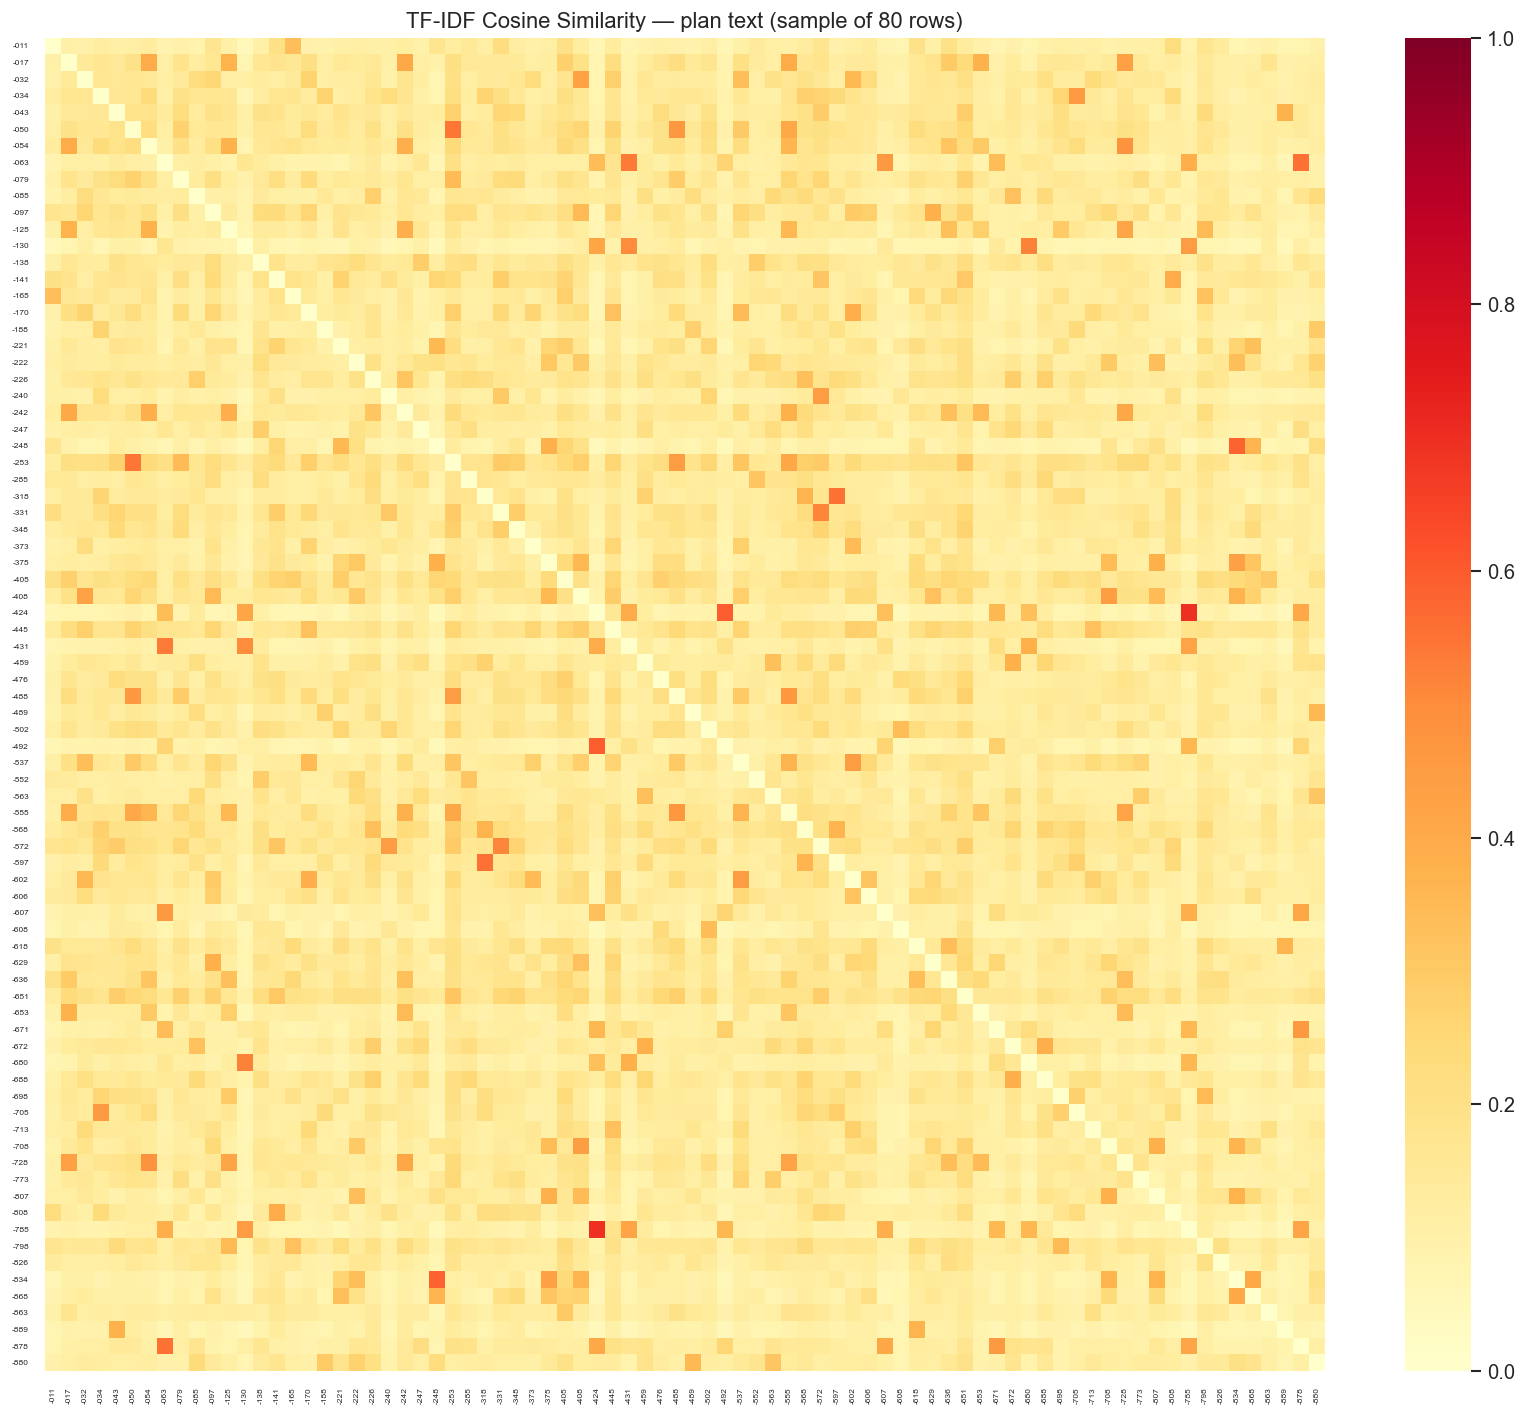

Saved: similarity_heatmap.png


In [ ]:
if rows and sim_matrix is not None and len(rows) > 5:
    sample_size    = min(80, len(rows))
    sample_indices = np.random.choice(len(rows), sample_size, replace=False)
    sample_indices.sort()

    sub_matrix = sim_matrix[np.ix_(sample_indices, sample_indices)]
    sub_ids    = [text_ids[i][-4:] for i in sample_indices]

    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    sns.heatmap(sub_matrix, ax=ax, cmap='YlOrRd', vmin=0, vmax=1, xticklabels=sub_ids, yticklabels=sub_ids)
    ax.set_title(f'TF-IDF Cosine Similarity — plan text (sample of {sample_size} rows)')
    plt.xticks(fontsize=5, rotation=90)
    plt.yticks(fontsize=5)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'similarity_heatmap.png', bbox_inches='tight')
    plt.show()
    print("Saved: similarity_heatmap.png")

---
## Section 9 - Bias Detection

Statistical methods to detect systematic biases that would cause the fine-tuned model
to plan unevenly across input types:

1. **Plan length by project class**: ANOVA — do some classes get disproportionately longer plans?
2. **Technology concentration**: Gini coefficient of tech-name frequency
3. **Plan quality by project class**: does any class systematically receive inflated quality labels?
4. **Length-quality correlation**: do longer plans always get higher quality labels regardless of content?

In [46]:
if rows:
    analysis_rows = []
    tech_terms_found = Counter()

    for row in rows:
        profile  = row.get('profile', {})
        meta     = row.get('metadata', {})
        output   = row.get('target_output', {})
        payload  = row.get('input_payload', {})
        sid      = row.get('sample_id', '')

        plan_text = extract_text_for_similarity(row).lower()
        for t in TECH_TERMS:
            if t in plan_text:
                tech_terms_found[t] += 1

        richness = richness_data.get(sid, {})
        pq_map = {'low': 1, 'moderate': 2, 'good': 3, 'high': 4}

        analysis_rows.append({
            'sample_id':        sid,
            'project_class':    profile.get('project_class', ''),
            'risk_level':       profile.get('risk_level', ''),
            'data_sensitivity': profile.get('data_sensitivity', ''),
            'external_exposure': profile.get('external_exposure', ''),
            'complexity_level': profile.get('complexity_level', ''),
            'case_type':        meta.get('case_type', ''),
            'plan_quality':     meta.get('plan_quality', ''),
            'plan_quality_num': pq_map.get(meta.get('plan_quality', ''), np.nan),
            'primary_theme':    meta.get('primary_theme', ''),
            'round':            payload.get('round', 0),
            'n_capabilities':   len(profile.get('capabilities', [])),
            'total_words':      richness.get('total_words', 0),
            'tech_terms':       richness.get('tech_term_count', 0),
            'stub_count':       richness.get('stub_section_count', 0),
            'fix_depth':        richness.get('fix_report_depth', 0.0),
            'n_issues':         len(payload.get('issue_ledger', {})),
            'n_focus':          len(payload.get('focus_issues', [])),
            'n_fix_items':      len(output.get('fix_report', [])),
        })

    df = pd.DataFrame(analysis_rows)

    print(f"{'='*60}")
    print(f"BIAS DETECTION REPORT")
    print(f"{'='*60}")

    # 1. Plan length by project class — ANOVA
    print(f"\n── Plan Length by Project Class (ANOVA) ──")
    classes_with_data = [c for c in df['project_class'].unique()
                         if len(df[df['project_class'] == c]) >= 3]
    if len(classes_with_data) >= 2:
        groups  = [df[df['project_class'] == c]['total_words'].values for c in classes_with_data]
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  ⚠ Significant plan-length-by-class bias detected (p < 0.05)")
            class_means = df.groupby('project_class')['total_words'].mean().sort_values()
            print(f"  Shortest avg: {class_means.index[0]} ({class_means.iloc[0]:.0f} words)")
            print(f"  Longest avg:  {class_means.index[-1]} ({class_means.iloc[-1]:.0f} words)")
        else:
            print("  ✓ No significant plan-length-by-class bias")
    else:
        print("  Insufficient class diversity for ANOVA")

    # 2. Plan quality by project class
    print(f"\n── Plan Quality Label by Project Class ──")
    if 'plan_quality_num' in df.columns:
        classes_pq = [c for c in df['project_class'].unique()
                      if len(df[(df['project_class'] == c) & df['plan_quality_num'].notna()]) >= 3]
        if len(classes_pq) >= 2:
            grps_pq = [df[(df['project_class'] == c) & df['plan_quality_num'].notna()]['plan_quality_num'].values
                       for c in classes_pq]
            f2, p2 = stats.f_oneway(*grps_pq)
            print(f"F-statistic: {f2:.3f}, p-value: {p2:.4f}")
            if p2 < 0.05:
                print("  ⚠ Significant plan-quality-by-class bias detected")
            else:
                print("  ✓ No significant plan-quality-by-class bias")

    # 3. Length-quality correlation
    print(f"\n── Length-Quality Correlation ──")
    valid = df.dropna(subset=['plan_quality_num'])
    if len(valid) > 5:
        r_len, p_len = stats.pearsonr(valid['total_words'], valid['plan_quality_num'])
        print(f"r={r_len:.3f}, p={p_len:.4f}")
        if r_len > 0.5:
            print("  ⚠ Strong positive correlation — quality labels may be inflated by plan length alone")
        else:
            print("  ✓ Acceptable length-quality correlation")

    # 4. Technology concentration — Gini
    print(f"\n── Technology Term Concentration (Gini) ──")
    if tech_terms_found:
        tf_vals = np.array(sorted(tech_terms_found.values()))
        n = len(tf_vals)
        gini = (2 * np.sum((np.arange(1, n+1)) * tf_vals) / (n * np.sum(tf_vals))) - (n + 1) / n
        print(f"Gini coefficient: {gini:.3f}")
        if gini > 0.7:
            print("  ⚠ High tech concentration — model may overfit to a narrow stack")
        else:
            print("  ✓ Reasonable tech diversity")
        print(f"Top 5 most mentioned technologies:")
        for t, c in tech_terms_found.most_common(5):
            print(f"  {t}: {c}")
else:
    df = pd.DataFrame()
    tech_terms_found = Counter()

BIAS DETECTION REPORT

── Plan Length by Project Class (ANOVA) ──
F-statistic: 13.035, p-value: 0.0000
  ⚠ Significant plan-length-by-class bias detected (p < 0.05)
  Shortest avg: landing_page (1278 words)
  Longest avg:  ai_system (1577 words)

── Plan Quality Label by Project Class ──
F-statistic: nan, p-value: nan
  ✓ No significant plan-quality-by-class bias

── Length-Quality Correlation ──
r=nan, p=nan
  ✓ Acceptable length-quality correlation

── Technology Term Concentration (Gini) ──
Gini coefficient: 0.572
  ✓ Reasonable tech diversity
Top 5 most mentioned technologies:
  sse: 764
  rds: 738
  github actions: 627
  postgres: 505
  docker: 464


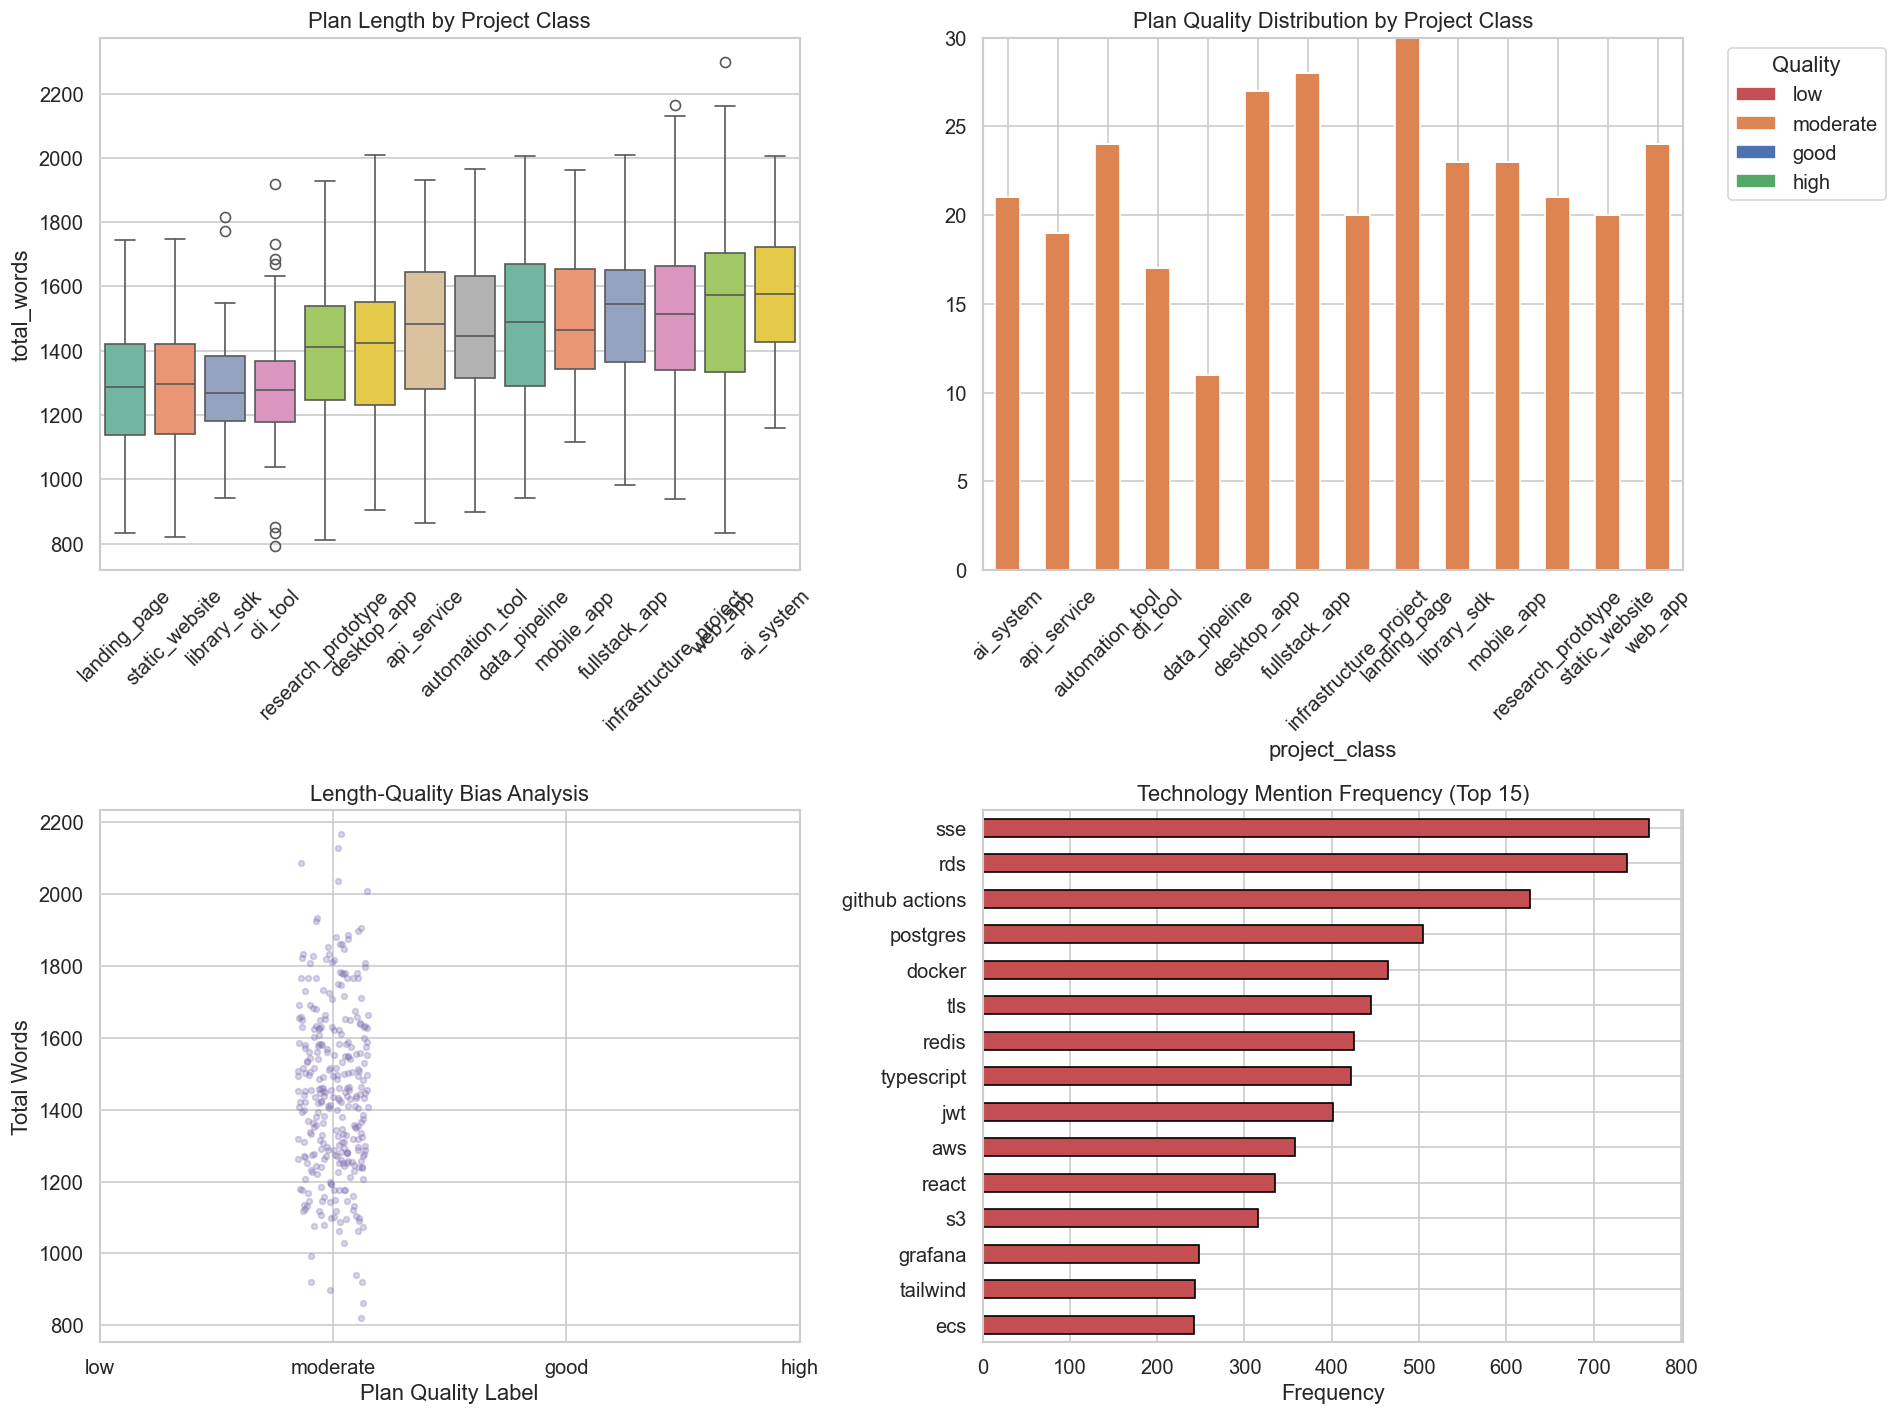

Saved: bias_analysis.png


In [47]:
if rows and len(df) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Plan length by project class
    class_order = df.groupby('project_class')['total_words'].mean().sort_values().index
    if len(class_order) > 1:
        sns.boxplot(data=df, x='project_class', y='total_words', order=class_order,
                    ax=axes[0, 0], palette='Set2')
        axes[0, 0].set_title('Plan Length by Project Class')
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].set_xlabel('')

    # 2. Plan quality label distribution by project class (stacked bar)
    if not df.empty and 'plan_quality' in df.columns:
        pq_by_class = df.groupby(['project_class', 'plan_quality']).size().unstack(fill_value=0)
        pq_by_class = pq_by_class.reindex(columns=['low','moderate','good','high'], fill_value=0)
        pq_by_class.plot(kind='bar', stacked=True, ax=axes[0, 1],
                         color=['#C44E52','#DD8452','#4C72B0','#55A868'])
        axes[0, 1].set_title('Plan Quality Distribution by Project Class')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].legend(title='Quality', bbox_to_anchor=(1.05, 1))

    # 3. Plan words vs quality scatter
    valid = df.dropna(subset=['plan_quality_num'])
    if len(valid) > 5:
        jitter = np.random.uniform(-0.15, 0.15, len(valid))
        axes[1, 0].scatter(valid['plan_quality_num'] + jitter, valid['total_words'],
                           alpha=0.3, s=12, color='#8172B3')
        axes[1, 0].set_xticks([1, 2, 3, 4])
        axes[1, 0].set_xticklabels(['low','moderate','good','high'])
        axes[1, 0].set_xlabel('Plan Quality Label')
        axes[1, 0].set_ylabel('Total Words')
        axes[1, 0].set_title('Length-Quality Bias Analysis')

    # 4. Technology frequency
    if tech_terms_found:
        top_techs = dict(tech_terms_found.most_common(15))
        tech_s = pd.Series(top_techs).sort_values()
        tech_s.plot(kind='barh', ax=axes[1, 1], color='#C44E52', edgecolor='black')
        axes[1, 1].set_xlabel('Frequency')
        axes[1, 1].set_title('Technology Mention Frequency (Top 15)')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'bias_analysis.png', bbox_inches='tight')
    plt.show()
    print("Saved: bias_analysis.png")

---
## Section 10 - Chain Progression Validation

For multi-round planning chains, validates temporal consistency:
- Round numbers are strictly sequential
- fix_report items in round N reference issues from the ledger that were unresolved in round N-1
- Resolved issues from prior rounds do not resurface as unresolved in the ledger
- Plan richness (word count) does not catastrophically regress across rounds
- revision_memory.last_score trajectory is plausible (no impossible jumps)

In [ ]:
def validate_chain_progression(chain: List[Dict]) -> List[Dict]:
    issues = []
    if len(chain) < 2:
        return issues

    for i in range(1, len(chain)):
        prev_row  = chain[i - 1]
        curr_row  = chain[i]
        prev_sid  = prev_row.get('sample_id', '?')
        curr_sid  = curr_row.get('sample_id', '?')
        prev_round = prev_row.get('input_payload', {}).get('round', 0)
        curr_round = curr_row.get('input_payload', {}).get('round', 0)

        # Rounds must be sequential
        if curr_round != prev_round + 1:
            issues.append({
                "chain_step": f"{prev_sid} -> {curr_sid}",
                "rule": "round_sequence",
                "detail": f"Rounds {prev_round} -> {curr_round} (expected {prev_round + 1})"
            })

        # Issues resolved in previous round should not reappear as unresolved in ledger
        prev_ledger = prev_row.get('input_payload', {}).get('issue_ledger', {})
        curr_ledger = curr_row.get('input_payload', {}).get('issue_ledger', {})

        prev_resolved = {
            iid for iid, issue in prev_ledger.items()
            if isinstance(issue, dict) and issue.get('status') == 'resolved'
        }
        curr_unresolved = {
            iid for iid, issue in curr_ledger.items()
            if isinstance(issue, dict) and issue.get('status') in ('unresolved', 'new')
        }
        zombie_issues = prev_resolved & curr_unresolved
        if zombie_issues:
            issues.append({
                "chain_step": f"{prev_sid} -> {curr_sid}",
                "rule": "zombie_issue",
                "detail": f"Issues resolved in round {prev_round} reappear unresolved: {zombie_issues}"
            })

        # Plan richness regression: current plan should not be substantially shorter than previous
        prev_richness = richness_data.get(prev_sid, {}).get('total_words', 0)
        curr_richness = richness_data.get(curr_sid, {}).get('total_words', 0)
        if prev_richness > 0 and curr_richness < prev_richness * 0.5:
            issues.append({
                "chain_step": f"{prev_sid} -> {curr_sid}",
                "rule": "richness_regression",
                "detail": f"Plan words dropped from {prev_richness} to {curr_richness} (>50% loss)"
            })

        # Score trajectory plausibility via revision_memory
        curr_rev_mem = curr_row.get('input_payload', {}).get('revision_memory', {})
        prev_rev_mem = prev_row.get('input_payload', {}).get('revision_memory', {})
        if isinstance(curr_rev_mem, dict) and isinstance(prev_rev_mem, dict):
            curr_score = curr_rev_mem.get('last_score')
            prev_score = prev_rev_mem.get('last_score')
            if curr_score is not None and prev_score is not None:
                jump = curr_score - prev_score
                if abs(jump) > 4:
                    issues.append({
                        "chain_step": f"{prev_sid} -> {curr_sid}",
                        "rule": "score_jump",
                        "detail": f"revision_memory.last_score jump of {jump:+.1f} ({prev_score} -> {curr_score})"
                    })

        # fix_report in current row should reference issues that were unresolved in previous round
        curr_fix = curr_row.get('target_output', {}).get('fix_report', [])
        curr_ledger_ids = set(curr_ledger.keys())
        prev_unresolved_ids = {
            iid for iid, issue in prev_ledger.items()
            if isinstance(issue, dict) and issue.get('status') in ('unresolved', 'new')
        }
        for fix_item in curr_fix:
            if isinstance(fix_item, dict):
                fid = fix_item.get('issue_id', '')
                if fid and fid not in curr_ledger_ids and fid not in prev_unresolved_ids:
                    issues.append({
                        "chain_step": f"{prev_sid} -> {curr_sid}",
                        "rule": "fixreport_ghost_id",
                        "detail": f"fix_report references '{fid}' which was not unresolved in prior round"
                    })
    return issues


if chains:
    chain_progression_results: Dict[str, List] = {}
    prog_rule_counts = Counter()

    for chain_id, chain in chains.items():
        if len(chain) < 2:
            continue
        prog_issues = validate_chain_progression(chain)
        if prog_issues:
            chain_progression_results[chain_id] = prog_issues
            for iss in prog_issues:
                prog_rule_counts[iss['rule']] += 1

    multi_chains_count = sum(1 for c in chains.values() if len(c) > 1)
    print(f"\n{'='*60}")
    print(f"CHAIN PROGRESSION VALIDATION REPORT")
    print(f"{'='*60}")
    print(f"Multi-round chains validated: {multi_chains_count}")
    print(f"Chains with progression issues: {len(chain_progression_results)}")
    print(f"\nRule violation counts:")
    for rule, cnt in prog_rule_counts.most_common():
        print(f"  {rule}: {cnt}")

    if chain_progression_results:
        print(f"\nSample issues (first 3 chains):")
        for chain_id, issues in list(chain_progression_results.items())[:3]:
            print(f"  Chain {chain_id[:8]}:")
            for iss in issues[:2]:
                print(f"    [{iss['rule']}] {iss['detail']}")
else:
    chain_progression_results = {}


CHAIN PROGRESSION VALIDATION REPORT
Multi-round chains validated: 0
Chains with progression issues: 0

Rule violation counts:


---
## Section 11 - Plan-Contract Alignment Detection

Proxy check: scan the plan's content sections for key terms derived from the frozen
requirement contract and flag rows where the plan appears to diverge from stated
requirements. This is not exhaustive — it's a structural proxy for the LLM judge in
Section 16 to evaluate at depth.

In [ ]:
ALIGNMENT_FIELD_MAP = {
    'frontend_stack':        ('technology_stack',),
    'backend_stack':         ('technology_stack', 'architecture_overview'),
    'data_platform':         ('technology_stack', 'data_model'),
    'hosting_target':        ('deployment_and_operations',),
    'security_baseline':     ('security_and_compliance',),
    'observability_baseline': ('observability',),
}


def detect_plan_contract_misalignment(row: Dict) -> List[Dict]:
    missed = []
    contract = row.get('input_payload', {}).get('frozen_requirement_contract', {})
    output   = row.get('target_output', {})

    for field, plan_sections in ALIGNMENT_FIELD_MAP.items():
        contract_value = contract.get(field, {}).get('value', '').lower().strip()
        if not contract_value:
            continue

        plan_text_parts = [
            str(output.get(sec, '')).lower() for sec in plan_sections
        ]
        plan_text = ' '.join(plan_text_parts)

        contract_terms = [t.strip() for t in re.split(r'[,;\s/]+', contract_value) if len(t.strip()) > 2]
        if not contract_terms:
            continue

        matches     = sum(1 for t in contract_terms if t in plan_text)
        match_ratio = matches / len(contract_terms)

        if match_ratio < 0.25:
            missed.append({
                "field":         field,
                "contract_value": contract_value[:120],
                "sections_checked": list(plan_sections),
                "match_ratio":   round(match_ratio, 2),
            })

    return missed


if rows:
    alignment_results: Dict[str, List] = {}
    field_miss_counts = Counter()

    for row in rows:
        sid    = row.get('sample_id', 'UNKNOWN')
        missed = detect_plan_contract_misalignment(row)
        if missed:
            alignment_results[sid] = missed
            for m in missed:
                field_miss_counts[m['field']] += 1

    print(f"\n{'='*60}")
    print(f"PLAN-CONTRACT ALIGNMENT REPORT")
    print(f"{'='*60}")
    print(f"Rows with potential alignment gaps: {len(alignment_results)} ({len(alignment_results)/len(rows)*100:.1f}%)")
    print(f"\nMissed contract fields (by frequency):")
    for field, count in field_miss_counts.most_common():
        print(f"  {field}: {count} rows")
else:
    alignment_results = {}


PLAN-CONTRACT ALIGNMENT REPORT
Rows with potential alignment gaps: 235 (26.6%)

Missed contract fields (by frequency):
  frontend_stack: 183 rows
  data_platform: 39 rows
  hosting_target: 27 rows
  backend_stack: 17 rows
  security_baseline: 2 rows
  observability_baseline: 1 rows


---
## Section 12 - Cleaning & Remediation Pipeline

Applies fixes based on all validation results. Actions are categorised:
- **REMOVE**: Rows with fatal structural errors or irreparable inconsistencies
- **FIX_ENUM**: Correct compact-form enum values to snake_case
- **FIX_KEY**: Rename unexpected key formats in nested structures
- **FIX_CONDITIONAL**: Inject missing conditional contract fields with derived defaults
- **FLAG_STUB**: Tag stub plans for manual review without auto-fixing
- **REMOVE_DUPE**: Remove exact and near-duplicate rows (keep richer copy)

In [ ]:
# Compact-form → snake_case value mappings
ENUM_COMPACT_TO_SNAKE = {
    'webapp':               'web_app',
    'fullstackapp':         'fullstack_app',
    'mobileapp':            'mobile_app',
    'desktopapp':           'desktop_app',
    'apiservice':           'api_service',
    'staticwebsite':        'static_website',
    'landingpage':          'landing_page',
    'clitool':              'cli_tool',
    'librarysdk':           'library_sdk',
    'automationtool':       'automation_tool',
    'datapipeline':         'data_pipeline',
    'aisystem':             'ai_system',
    'researchprototype':    'research_prototype',
    'infrastructureproject':'infrastructure_project',
    'localonly':            'local_only',
    'internalonly':         'internal_only',
    'privateauthenticated': 'private_authenticated',
    'partnerfacing':        'partner_facing',
    'publicinternet':       'public_internet',
    'highscale':            'high_scale',
    'adminpanel':           'admin_panel',
    'publicapi':            'public_api',
    'batchjobs':            'batch_jobs',
    'aillm':                'ai_llm',
    'pii':                  'personal',
    'phi':                  'health',
    'pci':                  'financial',
}


def fix_enum_value(value: str) -> str:
    return ENUM_COMPACT_TO_SNAKE.get(value.lower(), value)


def fix_enum_in_profile(profile: Dict) -> Dict:
    fixed = copy.deepcopy(profile)
    for field in ('project_class', 'complexity_level', 'risk_level', 'data_sensitivity', 'external_exposure'):
        if field in fixed and isinstance(fixed[field], str):
            fixed[field] = fix_enum_value(fixed[field])
    fixed['capabilities'] = [fix_enum_value(c) for c in fixed.get('capabilities', [])]
    return fixed


def fix_enum_in_contract(contract: Dict) -> Dict:
    fixed = copy.deepcopy(contract)
    for field in ('project_class', 'complexity_level', 'risk_level', 'data_sensitivity', 'external_exposure'):
        if field in fixed and isinstance(fixed[field], dict):
            val = fixed[field].get('value', '')
            if val:
                fixed[field]['value'] = fix_enum_value(val)
    return fixed


def add_missing_conditional_fields(row: Dict) -> Dict:
    row = copy.deepcopy(row)
    profile  = row.get('profile', {})
    contract = row.get('input_payload', {}).get('frozen_requirement_contract', {})
    caps     = profile.get('capabilities', [])
    risk     = profile.get('risk_level', '')
    sens     = profile.get('data_sensitivity', '')

    if 'ai_llm' in caps and 'llm_integration' not in contract:
        contract['llm_integration'] = {
            "value": "Standard LLM API integration via provider SDK",
            "source": "Derived",
            "confirmed": True,
            "rationale": "Capability ai_llm requires llm_integration to be specified",
            "updated_at": "2026-03-15T00:00:00Z"
        }
    needs_compliance = (
        risk == 'high' or
        sens in ('personal', 'financial', 'health', 'confidential') or
        'payments' in caps
    )
    if needs_compliance and 'compliance_context' not in contract:
        contract['compliance_context'] = {
            "value": f"Compliance posture required for risk={risk}, sensitivity={sens}",
            "source": "Derived",
            "confirmed": True,
            "rationale": "Risk/sensitivity profile requires compliance_context",
            "updated_at": "2026-03-15T00:00:00Z"
        }
    row['input_payload']['frozen_requirement_contract'] = contract
    return row


def remove_auditor_leak_keys(output: Dict) -> Dict:
    """Remove keys that belong to AuditorAgent output from target_output."""    
    return {k: v for k, v in output.items() if k not in AUDITOR_LEAK_KEYS}

In [ ]:
if rows:
    cleaned_rows = []
    cleaning_log = {
        'removed': [],
        'fixed_enums': 0,
        'fixed_conditionals': 0,
        'removed_auditor_keys': 0,
        'exact_dupes_removed': 0,
        'near_dupes_removed': 0,
        'stub_plans_flagged': 0,
        'total_fixes': 0,
    }

    # Rows to remove: FATAL structural errors
    fatal_ids = {
        sid for sid, viols in all_violations.items()
        if any(v['severity'] == 'FATAL' for v in viols)
    }
    cleaning_log['removed'] = list(fatal_ids)

    # Exact duplicates: keep first, remove rest
    exact_dupe_remove = set()
    for h, ids in exact_dupes.items():
        for dup_id in ids[1:]:
            exact_dupe_remove.add(dup_id)
    cleaning_log['exact_dupes_removed'] = len(exact_dupe_remove)

    # Near-duplicate removal: keep richer plan
    near_dupe_remove = set()
    if near_dupes:
        for nd in near_dupes:
            words_a = richness_data.get(nd['row_a'], {}).get('total_words', 0)
            words_b = richness_data.get(nd['row_b'], {}).get('total_words', 0)
            remove_id = nd['row_b'] if words_a >= words_b else nd['row_a']
            near_dupe_remove.add(remove_id)
    cleaning_log['near_dupes_removed'] = len(near_dupe_remove)

    remove_ids = fatal_ids | exact_dupe_remove | near_dupe_remove

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        if sid in remove_ids:
            continue

        cleaned = copy.deepcopy(row)

        # Fix compact-form enum values
        original_profile  = json.dumps(cleaned.get('profile', {}))
        cleaned['profile'] = fix_enum_in_profile(cleaned.get('profile', {}))
        contract = cleaned.get('input_payload', {}).get('frozen_requirement_contract', {})
        cleaned['input_payload']['frozen_requirement_contract'] = fix_enum_in_contract(contract)
        if json.dumps(cleaned.get('profile', {})) != original_profile:
            cleaning_log['fixed_enums'] += 1

        # Add missing conditional contract fields
        original_contract = json.dumps(cleaned.get('input_payload', {}).get('frozen_requirement_contract', {}))
        cleaned = add_missing_conditional_fields(cleaned)
        if json.dumps(cleaned.get('input_payload', {}).get('frozen_requirement_contract', {})) != original_contract:
            cleaning_log['fixed_conditionals'] += 1

        # Remove auditor-leak keys from target_output
        original_output = json.dumps(cleaned.get('target_output', {}))
        cleaned['target_output'] = remove_auditor_leak_keys(cleaned.get('target_output', {}))
        if json.dumps(cleaned.get('target_output', {})) != original_output:
            cleaning_log['removed_auditor_keys'] += 1

        # Flag stub plans in metadata.quality_flags
        richness = richness_data.get(sid, {})
        if richness.get('is_stub_plan', False):
            qf = cleaned.get('metadata', {}).get('quality_flags', [])
            if isinstance(qf, list) and 'stub_plan' not in qf:
                cleaned['metadata']['quality_flags'] = qf + ['stub_plan']
            cleaning_log['stub_plans_flagged'] += 1

        cleaned_rows.append(cleaned)

    # Fix plan_quality mislabelling: 'none' or missing with rich plan gets 'moderate'
    for row in cleaned_rows:
        meta    = row.get('metadata', {})
        richness = richness_data.get(row.get('sample_id', ''), {})
        pq = meta.get('plan_quality', '')
        if pq not in ALLOWED_PLAN_QUALITY:
            total_words = richness.get('total_words', 0)
            if total_words > 1000:
                meta['plan_quality'] = 'good'
            elif total_words > 400:
                meta['plan_quality'] = 'moderate'
            else:
                meta['plan_quality'] = 'low'

    cleaning_log['total_fixes'] = (
        cleaning_log['fixed_enums'] +
        cleaning_log['fixed_conditionals'] +
        cleaning_log['removed_auditor_keys']
    )

    print(f"\n{'='*60}")
    print(f"CLEANING PIPELINE SUMMARY")
    print(f"{'='*60}")
    print(f"Input rows    : {len(rows)}")
    print(f"Rows removed  : {len(remove_ids)} "f"(fatal={len(fatal_ids)}, exact_dupe={len(exact_dupe_remove)}, near_dupe={len(near_dupe_remove)})")
    print(f"Rows cleaned  : {len(cleaned_rows)}")
    print(f"\nFixes applied:")
    for k, v in cleaning_log.items():
        if k not in ('removed', 'total_fixes') and isinstance(v, int):
            print(f"  {k}: {v}")
    print(f"  total_fixes: {cleaning_log['total_fixes']}")
else:
    cleaned_rows = []
    cleaning_log = {}


CLEANING PIPELINE SUMMARY
Input rows    : 883
Rows removed  : 0 (fatal=0, exact_dupe=0, near_dupe=0)
Rows cleaned  : 883

Fixes applied:
  fixed_enums: 0
  fixed_conditionals: 0
  removed_auditor_keys: 0
  exact_dupes_removed: 0
  near_dupes_removed: 0
  stub_plans_flagged: 0
  total_fixes: 0


---
## Section 13 - Before vs After Evaluation

Recompute all validation metrics on the cleaned dataset and produce publication-quality
comparison tables and visualisations.

In [52]:
def compute_all_metrics(data: List[Dict], label: str) -> Dict[str, Any]:
    metrics = {'label': label, 'n_rows': len(data)}
    if not data:
        return metrics

    validator = SchemaValidator()

    # Structural compliance
    struct_violations = sum(1 for row in data if validator.validate_row(row))
    metrics['structural_compliance_rate'] = 1 - struct_violations / len(data)

    # Enum compliance
    enum_violations = sum(1 for row in data if validate_enums(row))
    metrics['enum_compliance_rate'] = 1 - enum_violations / len(data)

    # Cross-field compliance
    cf_violations = sum(1 for row in data if validate_cross_field(row))
    metrics['crossfield_compliance_rate'] = 1 - cf_violations / len(data)

    # Conditional field compliance
    cond_violations = sum(
        1 for row in data
        if any(i['rule'].startswith('conditional_') for i in validate_cross_field(row))
    )
    metrics['conditional_compliance_rate'] = 1 - cond_violations / len(data)

    # Plan richness: stub plan rate
    richness_issues = sum(1 for row in data if validate_plan_richness(row)[0])
    metrics['plan_richness_rate'] = 1 - richness_issues / len(data)

    # Mean plan words
    metrics['mean_plan_words'] = np.mean([
        compute_plan_richness(row.get('target_output', {}))['total_words'] for row in data
    ])

    # Mean tech term count
    metrics['mean_tech_terms'] = np.mean([
        compute_plan_richness(row.get('target_output', {}))['tech_term_count'] for row in data
    ])

    # Stub plan proportion
    metrics['stub_plan_pct'] = sum(
        1 for row in data
        if compute_plan_richness(row.get('target_output', {}))['is_stub_plan']
    ) / len(data)

    # Diversity
    pc_counts = Counter(r.get('profile', {}).get('project_class', '') for r in data)
    metrics['pc_entropy']            = compute_shannon_entropy(pc_counts)
    metrics['pc_normalised_entropy'] = metrics['pc_entropy'] / compute_max_entropy(len(ALLOWED_PROJECT_CLASSES))
    metrics['pc_classes_covered']    = len(pc_counts)

    cap_combos = len(set(
        tuple(sorted(r.get('profile', {}).get('capabilities', []))) for r in data
    ))
    metrics['capability_combos'] = cap_combos

    # Case type ratio
    fp = sum(1 for r in data if r.get('metadata', {}).get('case_type') == 'first_pass')
    rr = sum(1 for r in data if r.get('metadata', {}).get('case_type') == 'revision_round')
    metrics['fp_ratio']           = fp / max(fp + rr, 1)
    metrics['fp_ratio_deviation'] = abs(metrics['fp_ratio'] - 0.40)

    return metrics


if rows and cleaned_rows:
    before_metrics = compute_all_metrics(rows, 'Before')
    after_metrics  = compute_all_metrics(cleaned_rows, 'After')

    comparison_data = {}
    for key in set(before_metrics) | set(after_metrics):
        if key in ('label',):
            continue
        bv = before_metrics.get(key, 0)
        av = after_metrics.get(key, 0)
        if isinstance(bv, (int, float)) and isinstance(av, (int, float)):
            comparison_data[key] = {'before': bv, 'after': av, 'delta': av - bv}

    comparison_df = pd.DataFrame(comparison_data).T
    print(comparison_df.to_string())

                                  before        after     delta
pc_classes_covered             14.000000    14.000000  0.000000
capability_combos             213.000000   213.000000  0.000000
n_rows                        883.000000   883.000000  0.000000
mean_plan_words              1428.403171  1428.403171  0.000000
crossfield_compliance_rate      0.986410     0.986410  0.000000
fp_ratio                        0.403171     0.403171  0.000000
fp_ratio_deviation              0.003171     0.003171  0.000000
enum_compliance_rate            0.344281     0.985277  0.640997
stub_plan_pct                   0.000000     0.000000  0.000000
plan_richness_rate              0.994337     0.994337  0.000000
structural_compliance_rate      1.000000     1.000000  0.000000
mean_tech_terms                12.131370    12.131370  0.000000
conditional_compliance_rate     1.000000     1.000000  0.000000
pc_entropy                      3.807135     3.807135  0.000000
pc_normalised_entropy           0.999942

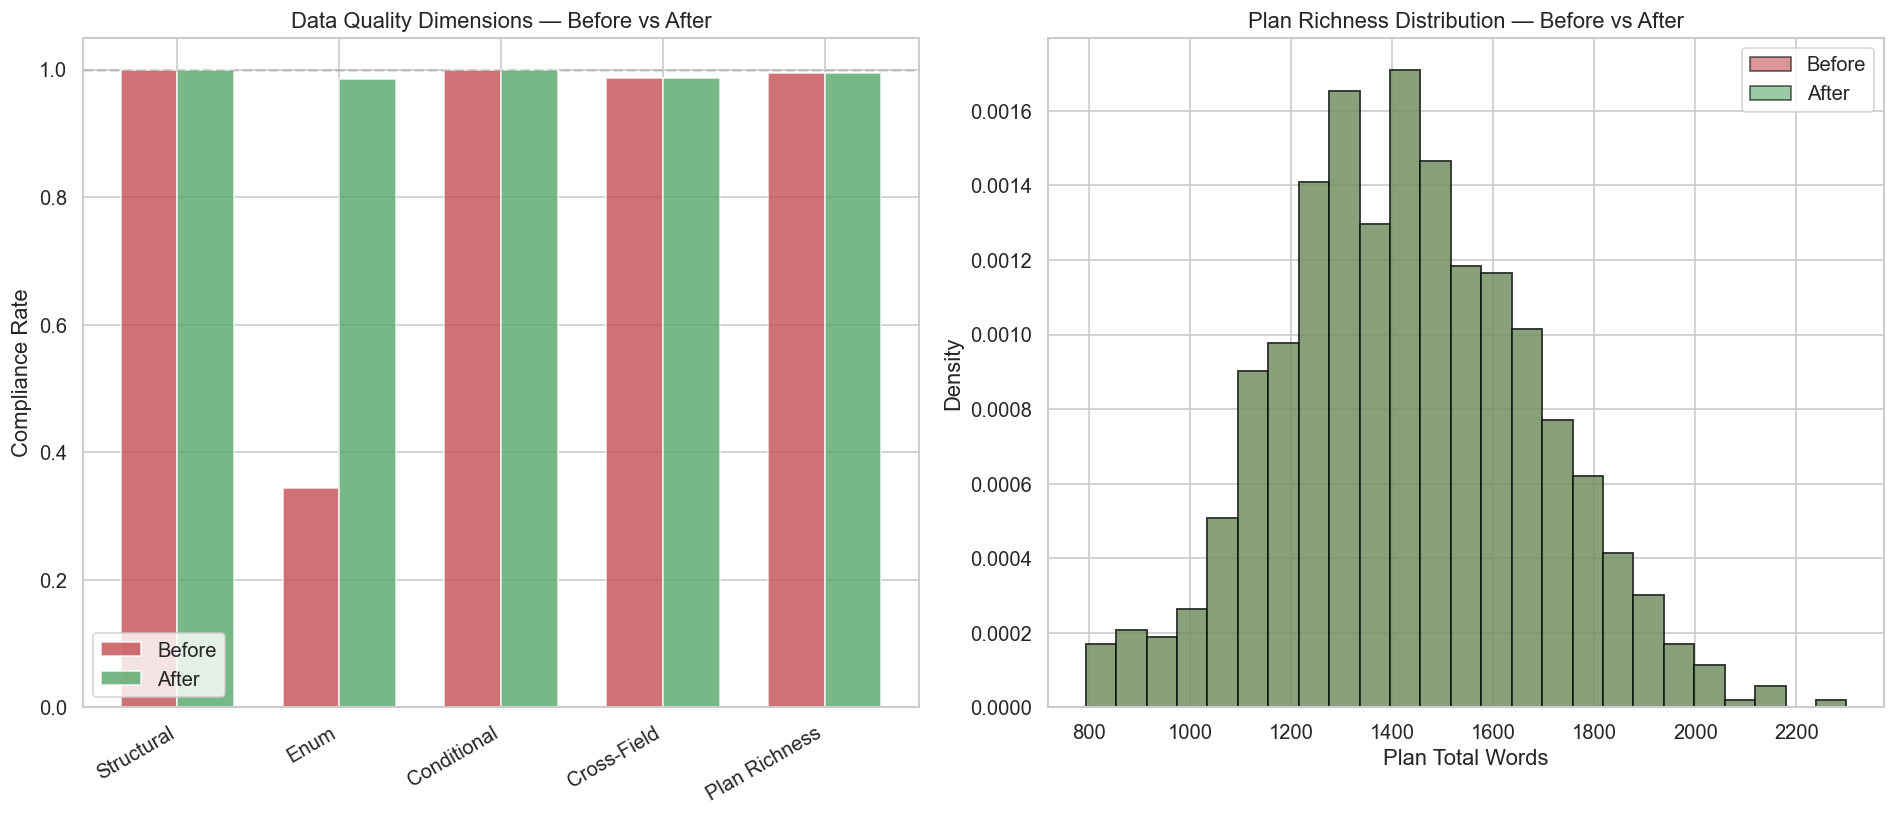

Saved: before_after_quality.png


In [53]:
if rows and cleaned_rows:
    quality_dims = [
        'structural_compliance_rate', 'enum_compliance_rate',
        'conditional_compliance_rate', 'crossfield_compliance_rate',
        'plan_richness_rate',
    ]
    dim_labels = ['Structural', 'Enum', 'Conditional', 'Cross-Field', 'Plan Richness']

    before_vals = [before_metrics.get(d, 0) for d in quality_dims]
    after_vals  = [after_metrics.get(d, 0) for d in quality_dims]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    x     = np.arange(len(dim_labels))
    width = 0.35
    axes[0].bar(x - width/2, before_vals, width, label='Before', color='#C44E52', alpha=0.8)
    axes[0].bar(x + width/2, after_vals,  width, label='After',  color='#55A868', alpha=0.8)
    axes[0].set_ylabel('Compliance Rate')
    axes[0].set_title('Data Quality Dimensions — Before vs After')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(dim_labels, rotation=30, ha='right')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()
    axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

    # Plan richness distribution comparison
    before_words = [compute_plan_richness(r.get('target_output', {}))['total_words'] for r in rows]
    after_words  = [compute_plan_richness(r.get('target_output', {}))['total_words'] for r in cleaned_rows]
    axes[1].hist(before_words, bins=25, alpha=0.6, label='Before', color='#C44E52', edgecolor='black', density=True)
    axes[1].hist(after_words,  bins=25, alpha=0.6, label='After',  color='#55A868', edgecolor='black', density=True)
    axes[1].set_xlabel('Plan Total Words')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Plan Richness Distribution — Before vs After')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'before_after_quality.png', bbox_inches='tight')
    plt.show()
    print("Saved: before_after_quality.png")

---
## Section 14 - Statistical Significance Tests

Verify that cleaning improvements are statistically significant using appropriate
non-parametric tests.

In [ ]:
if rows and cleaned_rows:
    print(f"\n{'='*60}")
    print(f"STATISTICAL SIGNIFICANCE TESTS")
    print(f"{'='*60}")

    # Test 1: Plan richness distribution shift (Wilcoxon)
    cleaned_id_map = {r.get('sample_id'): r for r in cleaned_rows}
    paired_before, paired_after = [], []
    for r in rows:
        sid = r.get('sample_id')
        if sid in cleaned_id_map:
            w_b = compute_plan_richness(r.get('target_output', {}))['total_words']
            w_a = compute_plan_richness(cleaned_id_map[sid].get('target_output', {}))['total_words']
            paired_before.append(w_b)
            paired_after.append(w_a)

    if len(paired_before) > 5:
        diffs = np.array(paired_after) - np.array(paired_before)
        non_zero = diffs[diffs != 0]
        if len(non_zero) > 0:
            stat, p_val = stats.wilcoxon(non_zero)
            print(f"\n1. Plan Richness Shift (Wilcoxon signed-rank test)")
            print(f"   Pairs with changes: {len(non_zero)}")
            print(f"   Mean change: {np.mean(non_zero):+.1f} words")
            print(f"   Statistic: {stat:.3f}, p-value: {p_val:.6f}")
            if p_val < 0.05:
                print(f"   ✓ Statistically significant (p < 0.05)")
            else:
                print(f"   Changes not statistically significant")
        else:
            print("\n1. No plan richness changes detected.")

    # Test 2: Project class uniformity (Chi-squared)
    all_classes      = sorted(ALLOWED_PROJECT_CLASSES)
    before_pc        = Counter(r.get('profile', {}).get('project_class', '') for r in rows)
    after_pc         = Counter(r.get('profile', {}).get('project_class', '') for r in cleaned_rows)
    before_observed  = [before_pc.get(c, 0) for c in all_classes]
    after_observed   = [after_pc.get(c, 0) for c in all_classes]
    exp_before       = [len(rows) / len(all_classes)] * len(all_classes)
    exp_after        = [len(cleaned_rows) / len(all_classes)] * len(all_classes)

    print(f"\n2. Project Class Uniformity (Chi-squared goodness of fit)")
    if sum(before_observed) > 0:
        chi2_b, p_b = stats.chisquare(before_observed, exp_before)
        print(f"   Before: chi2={chi2_b:.2f}, p={p_b:.6f}")
    if sum(after_observed) > 0:
        chi2_a, p_a = stats.chisquare(after_observed, exp_after)
        print(f"   After:  chi2={chi2_a:.2f}, p={p_a:.6f}")

    # Test 3: Plan richness by project class homogeneity improvement
    print(f"\n3. Plan Richness by Project Class (ANOVA before vs after)")
    before_df = pd.DataFrame([
        {'pc': r.get('profile', {}).get('project_class', ''), 'words': compute_plan_richness(r.get('target_output', {}))['total_words']}
        for r in rows
    ])
    after_df = pd.DataFrame([
        {'pc': r.get('profile', {}).get('project_class', ''), 'words': compute_plan_richness(r.get('target_output', {}))['total_words']}
        for r in cleaned_rows
    ])
    for label, d in [('Before', before_df), ('After', after_df)]:
        grps = [g['words'].values for _, g in d.groupby('pc') if len(g) >= 3]
        if len(grps) >= 2:
            f_, p_ = stats.f_oneway(*grps)
            print(f"   {label}: F={f_:.3f}, p={p_:.4f}")


STATISTICAL SIGNIFICANCE TESTS

1. No plan richness changes detected.

2. Project Class Uniformity (Chi-squared goodness of fit)
   Before: chi2=0.27, p=1.000000
   After:  chi2=0.27, p=1.000000

3. Plan Richness by Project Class (ANOVA before vs after)
   Before: F=13.035, p=0.0000
   After: F=13.035, p=0.0000


---
## Section 15 - Final Export

Export the cleaned dataset and all validation reports.

In [55]:
if cleaned_rows:
    output_path = OUTPUT_DIR / 'architect_dataset_cleaned.jsonl'
    with open(output_path, 'w', encoding='utf-8') as f:
        for row in cleaned_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
    size_kb = output_path.stat().st_size / 1024
    print(f"✓ Cleaned dataset exported: {output_path} ({len(cleaned_rows)} rows, {size_kb:.1f} KB)")

    if len(comparison_df) > 0:
        comparison_df.to_csv(OUTPUT_DIR / 'before_after_comparison.csv')
        print(f"✓ Comparison table exported")

    with open(OUTPUT_DIR / 'cleaning_log.json', 'w') as f:
        json.dump(cleaning_log, f, indent=2, default=str)
    print(f"✓ Cleaning log exported")

    reports = {
        'structural_violations':  {k: v for k, v in all_violations.items()},
        'enum_violations':        enum_results,
        'crossfield_violations':  {k: v for k, v in crossfield_results.items()},
        'richness_issues':        {k: v for k, v in richness_results.items()},
        'alignment_gaps':         {k: v for k, v in alignment_results.items()},
    }
    for name, data in reports.items():
        report_path = OUTPUT_DIR / f'{name}.json'
        with open(report_path, 'w') as f:
            json.dump(data, f, indent=2, default=str)
        print(f"✓ {name} exported")

    print(f"\n{'='*60}")
    print(f"ALL OUTPUTS SAVED TO: {OUTPUT_DIR}/")
    print(f"{'='*60}")
else:
    print("No cleaned data to export.")

✓ Cleaned dataset exported: validation_output\architect_dataset_cleaned.jsonl (883 rows, 26992.6 KB)
✓ Comparison table exported
✓ Cleaning log exported
✓ structural_violations exported
✓ enum_violations exported
✓ crossfield_violations exported
✓ richness_issues exported
✓ alignment_gaps exported

ALL OUTPUTS SAVED TO: validation_output/


---
## Section 16 - LLM-as-a-Judge Semantic Validation

GPT-based semantic quality gate. Each row is evaluated across 6 dimensions;
rows scoring below the threshold are excluded from the final dataset.

**Evaluation dimensions:**
1. `PLAN_SPECIFICITY` — named technologies, concrete component names, real data flows
2. `PLAN_COMPLETENESS` — all 16 content sections are substantive (not stubs)
3. `CONTRACT_PLAN_ALIGNMENT` — plan implements what the frozen contract requires
4. `FIX_REPORT_ACCURACY` — fix_report items accurately describe what changed (revision rows only)
5. `REVISION_INTEGRITY` — focus issues are genuinely addressed in the plan (revision rows only)
6. `IMPLEMENTATION_GRADE` — could a developer implement this from the plan as written?

In [ ]:
import time
import os
from openai import AzureOpenAI

# ═══════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════
client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY", ""),
    api_version="2024-12-01-preview",
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT", ""),
)
DEPLOYMENT_NAME = "gpt-5-chat"

INPUT_PATH  = str(OUTPUT_DIR / "architect_dataset_cleaned.jsonl")
LLM_OUT_DIR = OUTPUT_DIR / "llm_as_a_judge"
LLM_OUT_DIR.mkdir(exist_ok=True)
OUTPUT_PATH = str(LLM_OUT_DIR / "llm_validation_results.jsonl")
RESUME      = True

# ═══════════════════════════════════════════════════════════════
# JUDGE PROMPT
# ═══════════════════════════════════════════════════════════════
JUDGE_SYSTEM_PROMPT = """You are a senior AI data quality auditor evaluating synthetic training rows for an architectural planning ArchitectAgent.

Each row contains:
- A frozen requirement contract (what the client confirmed they want)
- An input context (reasoner reviews, specialist subplans, issue ledger, focus issues)
- A target_output (the architecture plan the ArchitectAgent is supposed to learn to produce)

Your job is to score the QUALITY of this training example across 6 dimensions.
For each dimension, give a score from 1-10 and a one-sentence justification.

DIMENSIONS:

1. PLAN_SPECIFICITY (1-10): Does the plan name real technologies concretely? Named stacks, specific services, real tools = high score. Generic phrases like "a suitable database" or "industry-standard framework" = low score. A score of 8+ requires at least 5 named technology choices throughout the plan.

2. PLAN_COMPLETENESS (1-10): Are all 16 content sections substantive? Stub sections (single words, "Standard", "TBD", fewer than 20 words) drag this score down. If 4 or more sections are stubs, score is 3 or below.

3. CONTRACT_PLAN_ALIGNMENT (1-10): Does the plan implement exactly what the frozen contract specifies? Check:
    - Is the frontend_stack from the contract reflected in the plan's technology_stack?
    - Is the backend_stack from the contract implemented in system_components/architecture_overview?
    - Is the data_platform from the contract used in data_model?
    - Is the hosting_target from the contract reflected in deployment_and_operations?
    A plan that ignores the contract and uses different technology choices without explanation = score 2 or below.

4. FIX_REPORT_ACCURACY (1-10): For revision_round rows: does each fix_report item accurately describe a real change made to the plan? "action_taken" must reference specific plan sections and what changed. Vague entries like "improved the architecture" = low score. For first_pass rows: score 10 if fix_report is empty (correct), 5 if it has entries (suspicious).

5. REVISION_INTEGRITY (1-10): For revision_round rows: are the focus issues from the issue_ledger genuinely addressed in the plan? The plan must show concrete evidence of addressing each focus issue. If focus_issues are non-empty but the plan shows no corresponding change = score 1. For first_pass rows: score this 10.

6. IMPLEMENTATION_GRADE (1-10): Could a senior developer begin implementing this from the plan alone? Check: Are component interfaces described? Are data schemas outlined? Are API endpoints or event contracts specified? Are deployment steps concrete? A score of 8+ requires all four to be present and substantive.

Return ONLY valid JSON with this exact structure:
{
    "plan_specificity": {"score": N, "justification": "..."},
    "plan_completeness": {"score": N, "justification": "..."},
    "contract_plan_alignment": {"score": N, "justification": "..."},
    "fix_report_accuracy": {"score": N, "justification": "..."},
    "revision_integrity": {"score": N, "justification": "..."},
    "implementation_grade": {"score": N, "justification": "..."},
    "overall_quality": N,
    "verdict": "KEEP" | "NEEDS_REPAIR" | "REMOVE",
    "critical_problems": ["..."]
}

overall_quality = mean of all 6 dimension scores, rounded to 1 decimal.
verdict:
    KEEP          → overall_quality >= 7.0 and no critical problems
    NEEDS_REPAIR  → overall_quality >= 5.0 but has fixable problems
    REMOVE        → overall_quality < 5.0 or has unfixable problems (plan is pure filler, contract ignored, stub throughout)
critical_problems: list of the most serious issues found (max 3, empty list if none).
"""


def build_judge_prompt(row: Dict) -> str:
    profile  = row.get('profile', {})
    payload  = row.get('input_payload', {})
    output   = row.get('target_output', {})
    meta     = row.get('metadata', {})

    contract_summary = {
        k: v.get('value', '') if isinstance(v, dict) else v
        for k, v in payload.get('frozen_requirement_contract', {}).items()
        if k in ('project_goal', 'frontend_stack', 'backend_stack', 'data_platform', 'hosting_target', 'security_baseline', 'observability_baseline')
    }

    focus_issue_titles = [
        fi.get('title', fi.get('id', str(fi))) if isinstance(fi, dict) else str(fi)
        for fi in payload.get('focus_issues', [])
    ]

    fix_report_summary = [
        {"issue_id": item.get('issue_id', ''), "action_taken": str(item.get('action_taken', ''))[:200], "changed_sections": item.get('changed_sections', [])}
        for item in output.get('fix_report', [])[:5]
        if isinstance(item, dict)
    ]

    plan_excerpt = {
        section: str(output.get(section, ''))[:300]
        for section in ['executive_summary', 'technology_stack', 'system_components',
                        'data_model', 'deployment_and_operations', 'security_and_compliance']
    }

    prompt_data = {
        "sample_id":       row.get('sample_id', ''),
        "case_type":       meta.get('case_type', ''),
        "round":           payload.get('round', 1),
        "project_class":   profile.get('project_class', ''),
        "capabilities":    profile.get('capabilities', []),
        "contract_summary": contract_summary,
        "focus_issues":    focus_issue_titles,
        "fix_report":      fix_report_summary,
        "plan_title":      output.get('title', ''),
        "plan_sections_present": [s for s in PLAN_CONTENT_SECTIONS if output.get(s)],
        "plan_excerpt":    plan_excerpt,
        "plan_quality_label": meta.get('plan_quality', ''),
    }
    return json.dumps(prompt_data, ensure_ascii=False, indent=2)

In [61]:
# ═══════════════════════════════════════════════════════════════
# RUN LLM VALIDATION
# ═══════════════════════════════════════════════════════════════

evaluation_rows = []
with open(INPUT_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                evaluation_rows.append(json.loads(line))
            except json.JSONDecodeError:
                pass

print(f"Rows to evaluate: {len(evaluation_rows)}")

# Resume from checkpoint
evaluated_ids = set()
if RESUME and Path(OUTPUT_PATH).exists():
    with open(OUTPUT_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    result = json.loads(line)
                    evaluated_ids.add(result.get('sample_id', ''))
                except json.JSONDecodeError:
                    pass
    print(f"Resuming: {len(evaluated_ids)} already evaluated")

todo = [r for r in evaluation_rows if r.get('sample_id', '') not in evaluated_ids]
print(f"Remaining: {len(todo)}")

with open(OUTPUT_PATH, 'a', encoding='utf-8') as out_f:
    for i, row in enumerate(todo):
        sid = row.get('sample_id', f'row_{i}')
        try:
            response = client.chat.completions.create(
                model=DEPLOYMENT_NAME,
                messages=[
                    {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                    {"role": "user",   "content": build_judge_prompt(row)},
                ],
                temperature=0.1,
                max_tokens=800,
            )
            raw = response.choices[0].message.content.strip()
            raw = re.sub(r'^```json\s*', '', raw)
            raw = re.sub(r'\s*```$', '', raw)
            result = json.loads(raw)
            result['sample_id']    = sid
            result['case_type']    = row.get('metadata', {}).get('case_type', '')
            result['projectclass'] = row.get('profile', {}).get('project_class', '')
            result['round']        = row.get('input_payload', {}).get('round', 1)
            out_f.write(json.dumps(result, ensure_ascii=False) + '\n')
            out_f.flush()

            if (i + 1) % 50 == 0:
                print(f"  [{i+1}/{len(todo)}] Evaluated {sid}")

        except Exception as e:
            error_result = {
                "sample_id": sid, "error": str(e),
                "overall_quality": 0, "verdict": "ERROR"
            }
            out_f.write(json.dumps(error_result, ensure_ascii=False) + '\n')
            out_f.flush()

        time.sleep(0.3)

print(f"\nLLM validation complete. Results saved to {OUTPUT_PATH}")

Rows to evaluate: 883
Remaining: 883
  [50/883] Evaluated ARC-PLAN26-051
  [100/883] Evaluated ARC-PLAN26-100
  [150/883] Evaluated ARC-PLAN26-149
  [200/883] Evaluated ARC-PLAN26-201
  [250/883] Evaluated ARC-PLAN26-250
  [300/883] Evaluated ARC-PLAN26-300
  [350/883] Evaluated ARC-PLAN26-350
  [400/883] Evaluated ARC-PLAN26-400
  [450/883] Evaluated ARC-PLAN26-450
  [500/883] Evaluated ARC-PLAN26-508
  [550/883] Evaluated ARC-PLAN26-550
  [600/883] Evaluated ARC-PLAN26-596
  [650/883] Evaluated ARC-PLAN26-654
  [700/883] Evaluated ARC-PLAN26-700
  [750/883] Evaluated ARC-PLAN26-742
  [800/883] Evaluated ARC-PLAN26-838
  [850/883] Evaluated ARC-PLAN26-850

LLM validation complete. Results saved to validation_output\llm_as_a_judge\llm_validation_results.jsonl


In [62]:
# ═══════════════════════════════════════════════════════════════
# ANALYZE LLM RESULTS & APPLY THRESHOLD
# ═══════════════════════════════════════════════════════════════

RESULTS_PATH = str(LLM_OUT_DIR / "llm_validation_results.jsonl")
THRESHOLD    = 8.0

results = []
with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                results.append(json.loads(line))
            except json.JSONDecodeError:
                pass

print(f"Loaded {len(results)} evaluation results")

DIMS = ['plan_specificity', 'plan_completeness', 'contract_plan_alignment',
        'fix_report_accuracy', 'revision_integrity', 'implementation_grade']

records = []
for r in results:
    record = {
        'sample_id':       r.get('sample_id', ''),
        'case_type':       r.get('case_type', ''),
        'projectclass':    r.get('projectclass', ''),
        'round':           r.get('round', 0),
        'overall_quality': r.get('overall_quality', 0),
        'verdict':         r.get('verdict', ''),
    }
    for dim in DIMS:
        dim_data = r.get(dim, {})
        record[dim] = dim_data.get('score', 0) if isinstance(dim_data, dict) else 0
    record['critical_problems'] = r.get('critical_problems', [])
    records.append(record)

llm_df = pd.DataFrame(records)

print(f"\n{'='*60}")
print(f"LLM VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"\nOverall Quality Distribution:")
print(llm_df['overall_quality'].describe().to_string())
print(f"\nVerdict Distribution:")
print(llm_df['verdict'].value_counts().to_string())
print(f"\nDimension Means:")
for dim in DIMS:
    print(f"  {dim}: {llm_df[dim].mean():.2f}")

keep   = llm_df[llm_df['overall_quality'] >= THRESHOLD]
remove = llm_df[llm_df['overall_quality'] <  THRESHOLD]
print(f"\n{'='*60}")
print(f"THRESHOLD ANALYSIS (threshold={THRESHOLD})")
print(f"{'='*60}")
print(f"KEEP:   {len(keep)} rows ({len(keep)/max(len(llm_df),1)*100:.1f}%)")
print(f"REMOVE: {len(remove)} rows ({len(remove)/max(len(llm_df),1)*100:.1f}%)")
if len(remove) > 0:
    print(f"\nRemoved by project class:")
    print(remove['projectclass'].value_counts().to_string())

Loaded 883 evaluation results

LLM VALIDATION SUMMARY

Overall Quality Distribution:
count    883.000000
mean       9.199320
std        0.358062
min        6.300000
25%        9.000000
50%        9.200000
75%        9.500000
max        9.700000

Verdict Distribution:
verdict
KEEP            871
NEEDS_REPAIR     12

Dimension Means:
  plan_specificity: 9.36
  plan_completeness: 8.36
  contract_plan_alignment: 9.88
  fix_report_accuracy: 9.45
  revision_integrity: 9.81
  implementation_grade: 8.31

THRESHOLD ANALYSIS (threshold=8.0)
KEEP:   875 rows (99.1%)
REMOVE: 8 rows (0.9%)

Removed by project class:
projectclass
desktop_app        2
static_website     1
automation_tool    1
ai_system          1
landing_page       1
web_app            1
fullstack_app      1


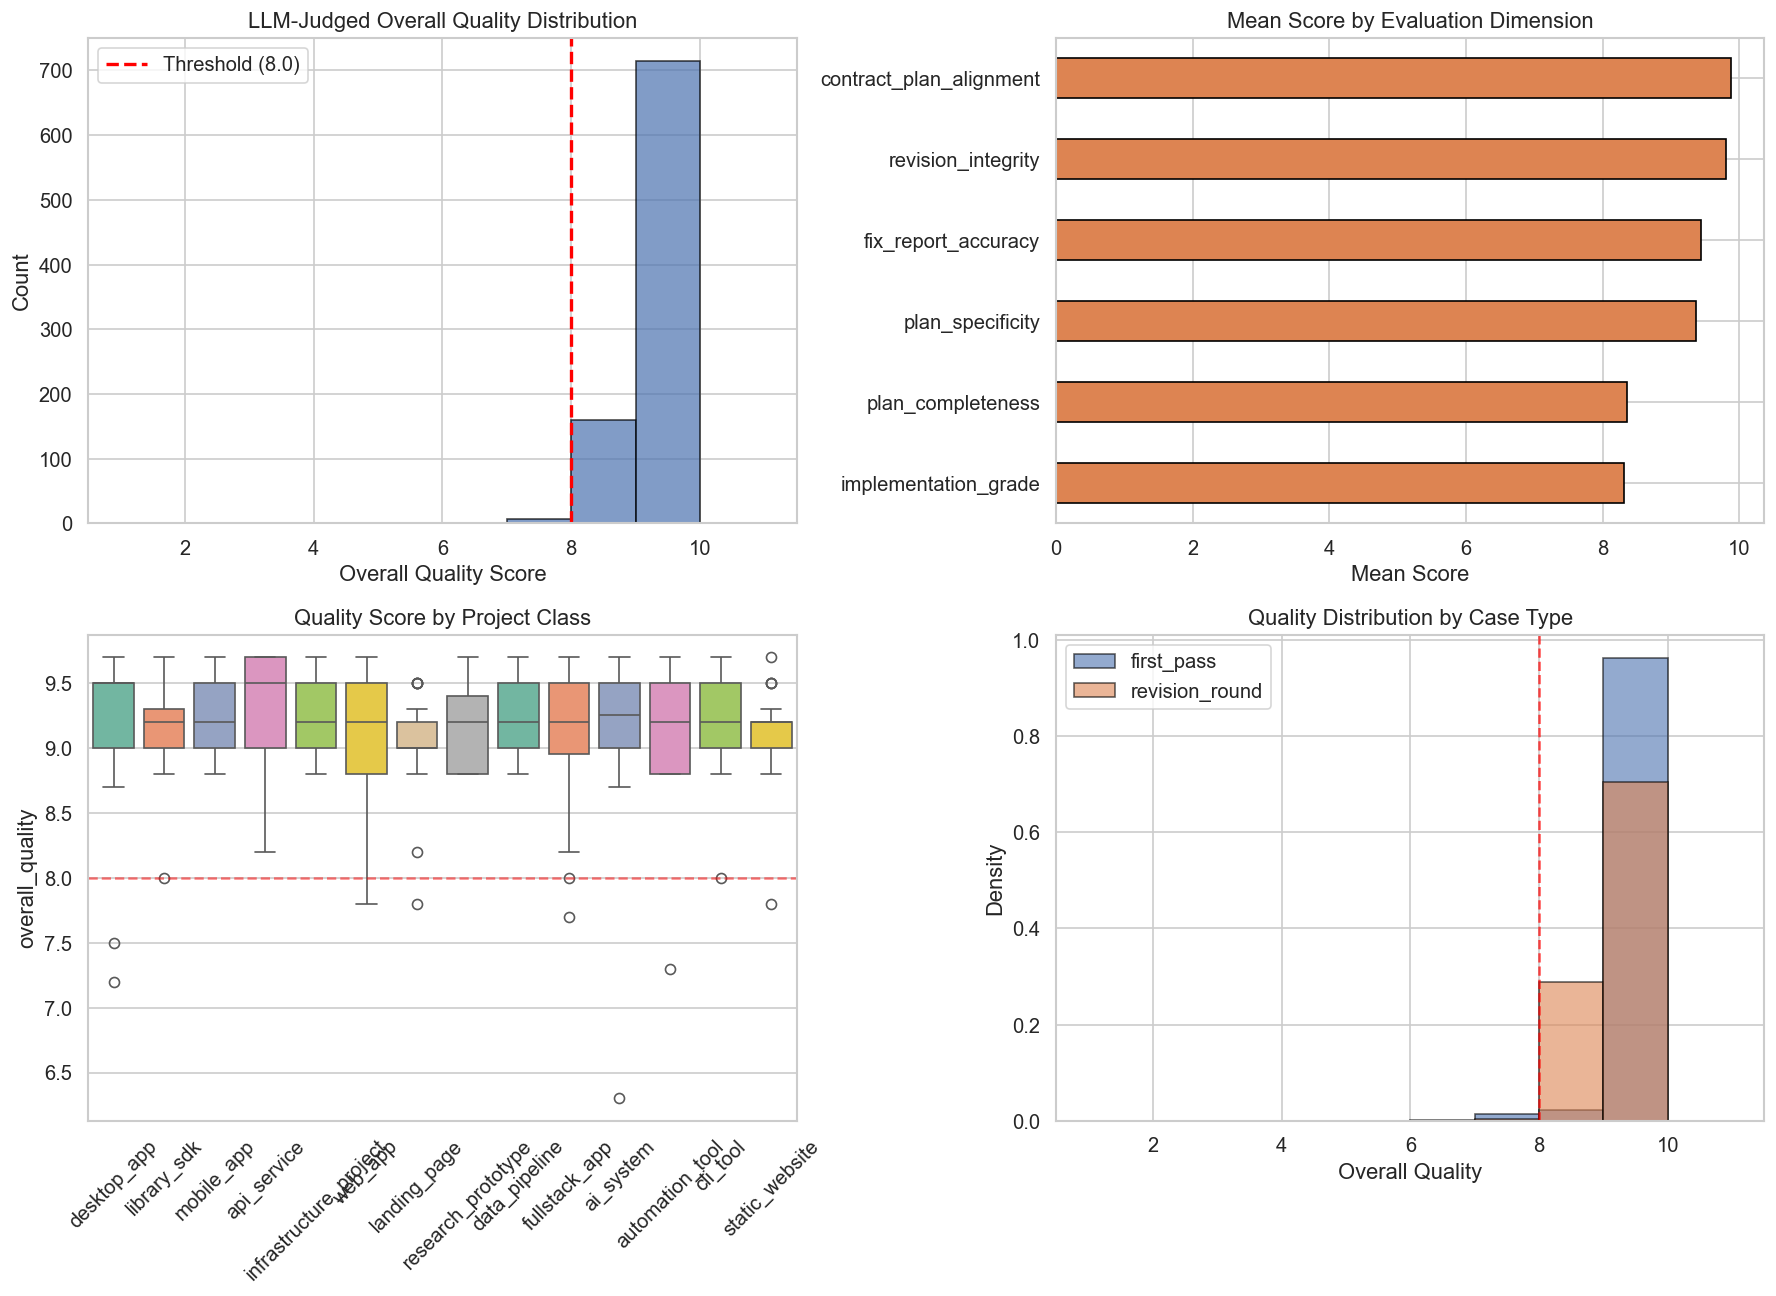

Saved: llm_quality_analysis.png


In [63]:
if len(llm_df) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    axes[0, 0].hist(llm_df['overall_quality'], bins=range(1, 12), edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0, 0].axvline(THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD})')
    axes[0, 0].set_xlabel('Overall Quality Score')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('LLM-Judged Overall Quality Distribution')
    axes[0, 0].legend()

    dim_means = {d: llm_df[d].mean() for d in DIMS}
    pd.Series(dim_means).sort_values().plot(kind='barh', ax=axes[0, 1], color='#DD8452', edgecolor='black')
    axes[0, 1].set_xlabel('Mean Score')
    axes[0, 1].set_title('Mean Score by Evaluation Dimension')

    if 'projectclass' in llm_df.columns and llm_df['projectclass'].nunique() > 1:
        sns.boxplot(data=llm_df, x='projectclass', y='overall_quality', ax=axes[1, 0], palette='Set2')
        axes[1, 0].set_title('Quality Score by Project Class')
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].set_xlabel('')
        axes[1, 0].axhline(THRESHOLD, color='red', linestyle='--', alpha=0.5)

    if 'case_type' in llm_df.columns:
        for ct, grp in llm_df.groupby('case_type'):
            axes[1, 1].hist(grp['overall_quality'], bins=range(1, 12),
                            alpha=0.6, edgecolor='black', label=ct, density=True)
        axes[1, 1].set_xlabel('Overall Quality')
        axes[1, 1].set_ylabel('Density')
        axes[1, 1].set_title('Quality Distribution by Case Type')
        axes[1, 1].axvline(THRESHOLD, color='red', linestyle='--', alpha=0.7)
        axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig(LLM_OUT_DIR / 'llm_quality_analysis.png', bbox_inches='tight')
    plt.show()
    print("Saved: llm_quality_analysis.png")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FINAL EXPORT — apply LLM threshold
# ═══════════════════════════════════════════════════════════════

keep_ids   = set(llm_df[llm_df['overall_quality'] >= THRESHOLD]['sample_id'].tolist())
final_rows = [r for r in cleaned_rows if r.get('sample_id') in keep_ids]

print(f"LLM validation approved: {len(keep_ids)} rows")
print(f"Final dataset size:      {len(final_rows)} rows")

final_pc = Counter(r.get('profile', {}).get('project_class', '') for r in final_rows)
final_ct = Counter(r.get('metadata', {}).get('case_type', '') for r in final_rows)
final_pq = Counter(r.get('metadata', {}).get('plan_quality', '') for r in final_rows)

print(f"\nProject classes : {dict(final_pc)}")
print(f"Case types      : {dict(final_ct)}")
print(f"Plan quality    : {dict(final_pq)}")

# Save keep IDs
import json as _json
with open(LLM_OUT_DIR / 'validation_keep_ids.json', 'w') as f:
    _json.dump(list(keep_ids), f, indent=2)

OUTPUT_FINAL = str(LLM_OUT_DIR / 'architect_dataset_final.jsonl')
with open(OUTPUT_FINAL, 'w', encoding='utf-8') as f:
    for row in final_rows:
        f.write(json.dumps(row, ensure_ascii=False) + '\n')

size_kb = Path(OUTPUT_FINAL).stat().st_size / 1024
print(f"\n✓ Final dataset exported: {OUTPUT_FINAL} ({size_kb:.1f} KB)")

LLM validation approved: 875 rows
Final dataset size:      875 rows

Project classes : {'desktop_app': 63, 'library_sdk': 62, 'mobile_app': 63, 'api_service': 63, 'infrastructure_project': 63, 'web_app': 62, 'landing_page': 62, 'research_prototype': 63, 'data_pipeline': 64, 'fullstack_app': 63, 'ai_system': 63, 'automation_tool': 60, 'cli_tool': 61, 'static_website': 63}
Case types      : {'revision_round': 524, 'first_pass': 351}
Plan quality    : {'good': 541, 'moderate': 334}

✓ Final dataset exported: validation_output\llm_as_a_judge\architect_dataset_final.jsonl (26775.1 KB)


: 

---
## Summary & Conclusions

This notebook implemented a comprehensive, chain-aware validation and cleaning pipeline for the
ArchitectAgent synthetic training dataset. The key contributions are:

1. **Chain Reconstruction**: Identified planning chains from shared frozen contracts, enabling
   chain-aware deduplication and round-progression validation
2. **Seven-Dimension Validation**: Structural schema, enum compliance, cross-field consistency
   (including fix-report/issue-ledger integrity), plan richness & anti-stub, diversity,
   duplication, and bias detection
3. **Architect-Specific Checks**: Auditor data contamination detection, compact-form enum
   correction, fix-report orphan ID detection, plan-contract alignment proxy scoring
4. **Intelligent Cleaning**: Enum normalisation, conditional field injection, Auditor key removal,
   stub plan flagging, and richness-guided near-duplicate resolution
5. **Quantitative Evidence**: Before/after comparison with Wilcoxon and Chi-squared tests
6. **LLM-as-a-Judge Gate**: GPT-scored semantic quality across 6 architect-specific dimensions

### Key Metrics for Thesis Reporting

| Dimension | Evidence |
|-----------|----------|
| Structural Integrity | Schema compliance rate improvement |
| Plan Richness | Word count distribution, stub plan reduction |
| Contract Alignment | Fix-report orphan rate, alignment proxy score |
| Diversity | Shannon entropy, project class coverage |
| Duplication | Near-duplicate reduction (chain-aware) |
| Bias | ANOVA F-statistics, length-quality correlation |
| Semantic Quality | LLM judge dimension means, threshold pass rate |